# Comparative Study of Classical Machine Learning untuk Pengenalan Aksara Nusantara


Notes: Notebook dirancang untuk dirun pada **Kaggle (GPU T4 x2)**.

# Setup Environment, Library & Path

In [1]:
import os
import sys
import time
import gc
import re
import json
import warnings
import zipfile
import subprocess
import multiprocessing
from math import pi
from pathlib import Path
from itertools import product, combinations
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import joblib
import optuna
from PIL import Image

from skimage.feature import hog, local_binary_pattern
from skimage.morphology import skeletonize
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, roc_curve, auc, roc_auc_score,
)

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style="whitegrid")

print("Library siap. Python:", sys.version.split()[0])

Library siap. Python: 3.12.12


In [2]:
# Deteksi environment dan tentukan path input/output
IS_KAGGLE = os.path.exists("/kaggle/input")
IS_COLAB = "google.colab" in sys.modules

try:
    _gpu = subprocess.run(
        ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"],
        capture_output=True, text=True, timeout=5,
    )
    GPU_AVAILABLE = _gpu.returncode == 0 and bool(_gpu.stdout.strip())
    GPU_INFO = _gpu.stdout.strip().split("\n")[0] if GPU_AVAILABLE else "tidak ada GPU"
except Exception:
    GPU_AVAILABLE = False
    GPU_INFO = "tidak ada GPU"

if IS_KAGGLE:
    WORK_ROOT = Path("/kaggle/working")
    INPUT_ROOT = Path("/kaggle/input")
else:
    WORK_ROOT = Path.cwd()
    INPUT_ROOT = Path.cwd()

OUTPUT_DIR = WORK_ROOT / "aksara_output"
FEATURES_DIR = OUTPUT_DIR / "features"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

# Folder contoh CSV: di repo lokal diarahkan ke notebooks/example_csv,
# di Kaggle diarahkan ke output supaya bisa diunduh lalu disalin ke repo.
if IS_KAGGLE:
    EXAMPLE_CSV_DIR = OUTPUT_DIR
else:
    EXAMPLE_CSV_DIR = WORK_ROOT / "notebooks" / "example_csv"
    EXAMPLE_CSV_DIR.mkdir(parents=True, exist_ok=True)


def has_script_folders(folder):
    if not folder.is_dir():
        return False
    names = {p.name.lower() for p in folder.iterdir() if p.is_dir()}
    return {"bali", "jawa", "sunda"}.issubset(names)


def find_dataset_root(search_roots, max_depth=8):
    for root in search_roots:
        root = Path(root)
        if not root.exists():
            continue
        if has_script_folders(root):
            return root
        for folder in root.rglob("*"):
            if not folder.is_dir():
                continue
            if len(folder.relative_to(root).parts) > max_depth:
                continue
            if has_script_folders(folder):
                return folder
    return None


DATASET_ROOT = find_dataset_root([INPUT_ROOT, WORK_ROOT])
if DATASET_ROOT is None:
    raise RuntimeError("Dataset tidak ditemukan. Pastikan folder Bali/Jawa/Sunda tersedia.")

print(f"Runtime      : {'Kaggle' if IS_KAGGLE else 'Colab' if IS_COLAB else 'lokal'}")
print(f"GPU          : {GPU_INFO}")
print(f"DATASET_ROOT : {DATASET_ROOT}")
print(f"OUTPUT_DIR   : {OUTPUT_DIR}")
print(f"CSV contoh   : {EXAMPLE_CSV_DIR}")

Runtime      : Kaggle
GPU          : Tesla T4
DATASET_ROOT : /kaggle/input/datasets/fadhlannurrachman/script-aksara
OUTPUT_DIR   : /kaggle/working/aksara_output
CSV contoh   : /kaggle/working/aksara_output


In [3]:
# Konfigurasi eksperiment T4x2
RANDOM_STATE = 42
IMG_SIZE = 96
TEST_SIZE = 0.20
VAL_SIZE = 0.15
MAX_PER_CLASS = 350

PCA_VARIANCE = 0.98
N_TRIALS = 10
TUNE_FRAC = 0.35
TUNING_TIMEOUT_SECONDS = 1800

AUGMENT_TRAIN = True
AUG_TARGET_PER_CLASS = 250
AUG_MAX_EXTRA_PER_IMAGE = 3

FEATURE_VERSION = f"v5_balance_img{IMG_SIZE}_pca{int(PCA_VARIANCE * 100)}_aug{AUG_TARGET_PER_CLASS}"

# Device boosting: GPU jika tersedia, kecuali LightGBM yang lebih stabil di CPU pada Kaggle
XGBOOST_DEVICE = "cuda" if GPU_AVAILABLE else "cpu"
CATBOOST_DEVICE = "GPU" if GPU_AVAILABLE else "CPU"

np.random.seed(RANDOM_STATE)

print("KONFIGURASI EKSPERIMEN")
print(f"  IMG_SIZE             = {IMG_SIZE}px")
print(f"  MAX_PER_CLASS        = {MAX_PER_CLASS}")
print(f"  PCA_VARIANCE         = {PCA_VARIANCE}")
print(f"  N_TRIALS (Optuna)    = {N_TRIALS}")
print(f"  TUNE_FRAC            = {TUNE_FRAC}")
print(f"  AUG_TARGET_PER_CLASS = {AUG_TARGET_PER_CLASS}")
print(f"  FEATURE_VERSION      = {FEATURE_VERSION}")
print(f"  XGBoost / CatBoost   = {XGBOOST_DEVICE} / {CATBOOST_DEVICE}")

KONFIGURASI EKSPERIMEN
  IMG_SIZE             = 96px
  MAX_PER_CLASS        = 350
  PCA_VARIANCE         = 0.98
  N_TRIALS (Optuna)    = 10
  TUNE_FRAC            = 0.35
  AUG_TARGET_PER_CLASS = 250
  FEATURE_VERSION      = v5_balance_img96_pca98_aug250
  XGBoost / CatBoost   = cuda / GPU


## 2. Load Dataset (Bali, Jawa, Sunda)

In [4]:
# Konfigurasi pemindaian tiap aksara: folder mana yang diambil dan dikecualikan
SCRIPT_CONFIG = {
    "Bali": {"hints": ["bali"], "include_parts": ["letter"]},
    "Jawa": {"hints": ["jawa", "java"], "include_parts": ["all_class"]},
    "Sunda": {"hints": ["sunda", "sundanese"], "include_parts": ["consonant", "vowel"]},
}
EXCLUDE_KEYWORDS = ["number", "numbers", "angka", "digit", "digits"]
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}


def is_digit_class(name):
    """Karakter angka dibuang; fokus hanya pada huruf/aksara."""
    s = name.strip().lower()
    if s.isdigit():
        return True
    return any(key in s for key in ["angka", "number", "digit", "num"])


def path_has_part(path, names):
    parts = [part.lower() for part in path.parts]
    return any(name.lower() in parts for name in names)


def collect_script_images(script_name, cfg):
    script_roots = [
        d for d in DATASET_ROOT.rglob("*")
        if d.is_dir() and d.name.lower() in cfg["hints"]
    ]
    images = []
    for root in set(script_roots):
        for p in root.rglob("*"):
            if not p.is_file() or p.suffix.lower() not in IMG_EXTS:
                continue
            if cfg["include_parts"] and not path_has_part(p, cfg["include_parts"]):
                continue
            if path_has_part(p, EXCLUDE_KEYWORDS):
                continue
            images.append(p)
    return list(set(images))


rng = np.random.RandomState(RANDOM_STATE)
records = []

for script_name, cfg in SCRIPT_CONFIG.items():
    images = collect_script_images(script_name, cfg)

    class_to_paths = {}
    for p in images:
        char_name = p.parent.name
        if is_digit_class(char_name):
            continue
        class_to_paths.setdefault(char_name, []).append(p)

    total = 0
    for char_name, paths in class_to_paths.items():
        if len(paths) > MAX_PER_CLASS:
            paths = list(rng.choice(paths, MAX_PER_CLASS, replace=False))
        total += len(paths)
        for p in paths:
            records.append({
                "filepath": str(p),
                "script": script_name,
                "character": char_name,
                "label": f"{script_name}_{char_name}",
            })
    print(f"{script_name:6s}: {len(class_to_paths):2d} kelas, {total:4d} gambar (cap {MAX_PER_CLASS}/kelas)")

df = pd.DataFrame(records)
if df.empty:
    raise RuntimeError("Dataset kosong, cek konfigurasi path.")

print(f"\nTotal gambar : {len(df):,}")
print(f"Total kelas  : {df['label'].nunique()}")
df.head()

Bali  : 18 kelas, 4493 gambar (cap 350/kelas)
Jawa  : 14 kelas, 4312 gambar (cap 350/kelas)
Sunda : 32 kelas, 11200 gambar (cap 350/kelas)

Total gambar : 20,005
Total kelas  : 64


,filepath,script,character,label
0,/kaggle/input/datasets/fadhlannurrachman/scrip...,Bali,pa,Bali_pa
1,/kaggle/input/datasets/fadhlannurrachman/scrip...,Bali,pa,Bali_pa
2,/kaggle/input/datasets/fadhlannurrachman/scrip...,Bali,pa,Bali_pa
3,/kaggle/input/datasets/fadhlannurrachman/scrip...,Bali,pa,Bali_pa
4,/kaggle/input/datasets/fadhlannurrachman/scrip...,Bali,pa,Bali_pa


#### Interpretasi cell diatas :

Dataset dibaca langsung dari struktur folder. Tiap aksara punya aturan folder yang berbeda seperti letter untuk Bali, all_class untuk Jawa, consonant/vowel untuk Sunda, dan kelas angka dibuang karena fokus penelitian adalah huruf. Setiap kelas dibatasi maksimum MAX_PER_CLASS gambar (smart downsampling) supaya kelas yang sangat banyak tidak mendominasi. Hasilnya adalah satu DataFrame df berisi kolom filepath, script, character, dan label gabungan Script_karakter.

# Exploratory Data Analysis (EDA)

,classes,samples,minimum_per_class,median_per_class,maximum_per_class,mean_per_class,standard_deviation,imbalance_ratio
script,,,,,,,,
Bali,18,4493,246,250.0,252,249.61,1.67,1.02
Jawa,14,4312,9,350.0,350,308.00,104.40,38.89
Sunda,32,11200,350,350.0,350,350.00,0.00,1.00


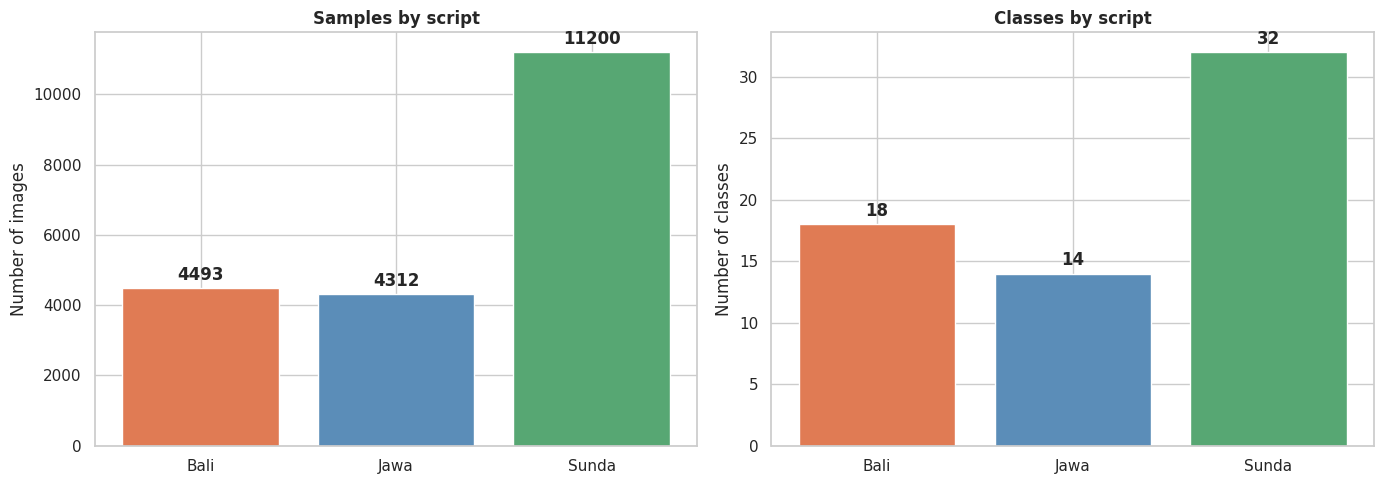

In [5]:
# Warna konsisten per aksara, dipakai di seluruh notebook
SCRIPT_COLORS = {"Bali": "#E07B54", "Jawa": "#5B8DB8", "Sunda": "#57A773"}

# Statistik ringkas per aksara: jumlah kelas, sampel, dan sebaran sampel per kelas
rows = []
for script in sorted(df["script"].unique()):
    counts = df[df["script"] == script]["label"].value_counts()
    rows.append({
        "script": script,
        "classes": int(counts.shape[0]),
        "samples": int(counts.sum()),
        "minimum_per_class": int(counts.min()),
        "median_per_class": float(counts.median()),
        "maximum_per_class": int(counts.max()),
        "mean_per_class": round(float(counts.mean()), 2),
        "standard_deviation": round(float(counts.std(ddof=0)), 2),
        "imbalance_ratio": round(float(counts.max() / counts.min()), 2),
    })
summary = pd.DataFrame(rows).set_index("script")
display(summary)

# Bar chart jumlah sampel dan jumlah kelas per aksara
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bar_colors = [SCRIPT_COLORS[s] for s in summary.index]
for ax, col, title, ylabel in [
    (axes[0], "samples", "Samples by script", "Number of images"),
    (axes[1], "classes", "Classes by script", "Number of classes"),
]:
    bars = ax.bar(summary.index, summary[col], color=bar_colors, edgecolor="white")
    ax.bar_label(bars, fmt="%d", padding=3, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_summary.png", dpi=120, bbox_inches="tight")
plt.show()

#### Interpretasi cell diatas :

Tabel statistik ringkas memperlihatkan ketimpangan data antar aksara. Sunda memiliki kelas terbanyak (32) dan jumlah sampel terbesar dengan sebaran sangat merata (standard deviation 0, imbalance ratio 1.0). Bali juga relatif seimbang. Sebaliknya, Jawa menunjukkan imbalance yang tinggi: ada kelas dengan sampel sangat sedikit (minimum jauh di bawah maksimum 350), sehingga standard deviation dan imbalance ratio-nya besar. Dua bar chart menegaskan bahwa jumlah sampel dan jumlah kelas didominasi Sunda. Temuan ini menjadi alasan kuat penerapan augmentasi train-only dan class weight balancing agar model tidak bias ke aksara berdata banyak.

Statistik ukuran gambar asli (sampel 400 gambar):


,width,height,aspect_ratio
count,400.00,400.00,400.00
mean,200.63,181.29,1.11
std,95.29,85.21,0.21
min,40.00,53.00,0.69
25%,124.00,116.50,1.00
50%,186.00,185.00,1.03
75%,253.00,187.75,1.13
max,393.00,348.00,2.14


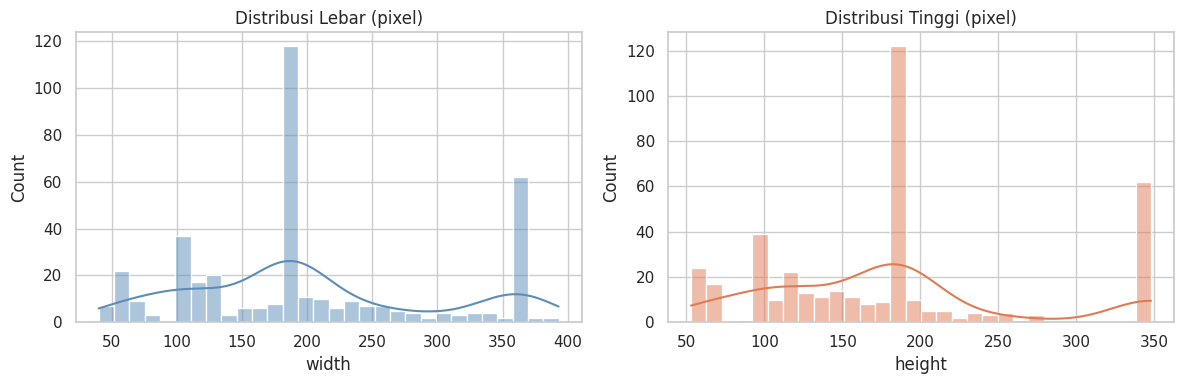

In [6]:
# Statistik ukuran pixel gambar asli (sampel acak agar cepat)
sample_paths = df["filepath"].sample(min(400, len(df)), random_state=RANDOM_STATE)
sizes = []
for fp in sample_paths:
    with Image.open(fp) as im:
        sizes.append(im.size)  # (width, height)

size_df = pd.DataFrame(sizes, columns=["width", "height"])
size_df["aspect_ratio"] = (size_df["width"] / size_df["height"]).round(3)
print("Statistik ukuran gambar asli (sampel {} gambar):".format(len(size_df)))
display(size_df.describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(size_df["width"], bins=30, kde=True, color="#5B8DB8", ax=axes[0])
axes[0].set_title("Distribusi Lebar (pixel)")
sns.histplot(size_df["height"], bins=30, kde=True, color="#E07B54", ax=axes[1])
axes[1].set_title("Distribusi Tinggi (pixel)")
plt.tight_layout()
plt.show()

#### Interpretasi cell diatas :

Ukuran gambar asli bervariasi (tidak seragam), sehingga preprocessing perlu menyeragamkan semua gambar ke ukuran tetap 96x96 pixel sebelum feature extraction. Distribusi lebar dan tinggi membantu memastikan target resize 96px masuk akal dan tidak terlalu memperbesar atau memperkecil mayoritas gambar.

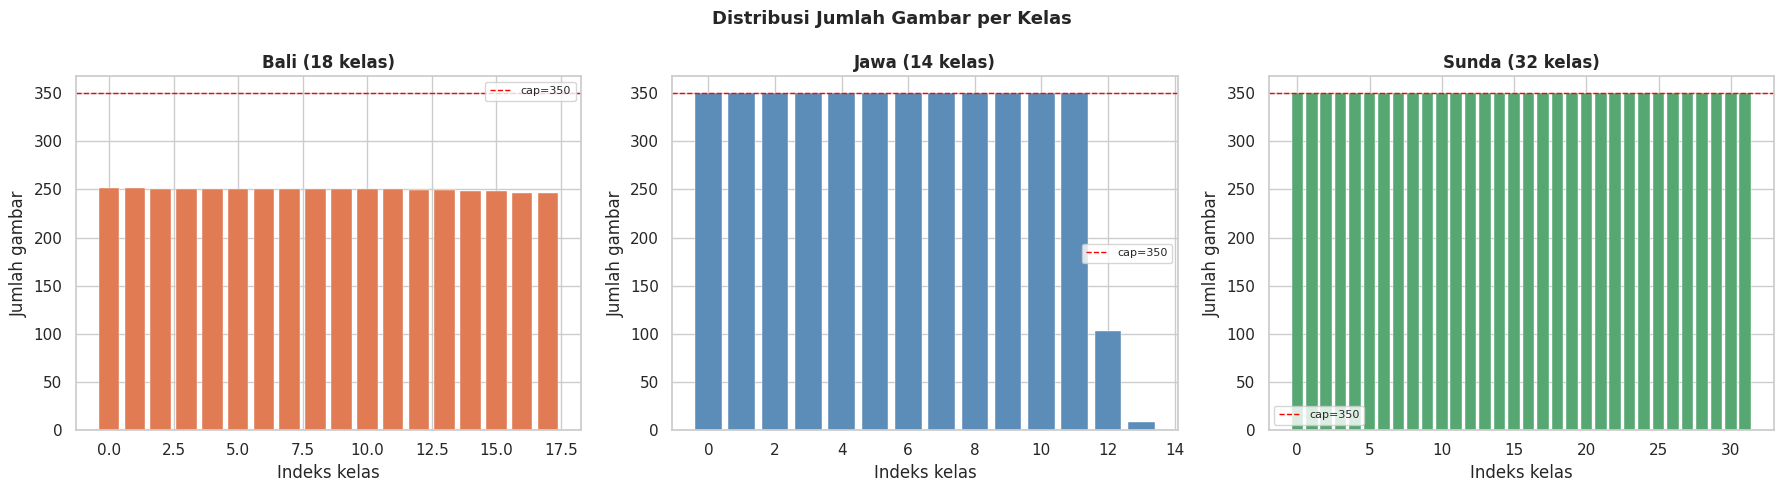

In [7]:
# Distribusi jumlah gambar per kelas, dipisah per aksara
scripts_sorted = sorted(df["script"].unique())
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribusi Jumlah Gambar per Kelas", fontsize=13, fontweight="bold")

for ax, script in zip(axes, scripts_sorted):
    counts = df[df["script"] == script]["label"].value_counts().sort_values(ascending=False)
    ax.bar(range(len(counts)), counts.values,
           color=SCRIPT_COLORS[script], edgecolor="white", linewidth=0.3)
    ax.axhline(MAX_PER_CLASS, color="red", linestyle="--", linewidth=1,
               label=f"cap={MAX_PER_CLASS}")
    ax.set_title(f"{script} ({len(counts)} kelas)", fontweight="bold")
    ax.set_xlabel("Indeks kelas")
    ax.set_ylabel("Jumlah gambar")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Interpretasi cell diatas :

Grafik batang memperlihatkan bahwa banyak kelas menyentuh batas atas garis merah, tetapi sebagian kelas lain jumlahnya jauh lebih sedikit. Ini adalah bentuk class imbalance yang akan ditangani lewat augmentasi train-only dan class weight balancing.

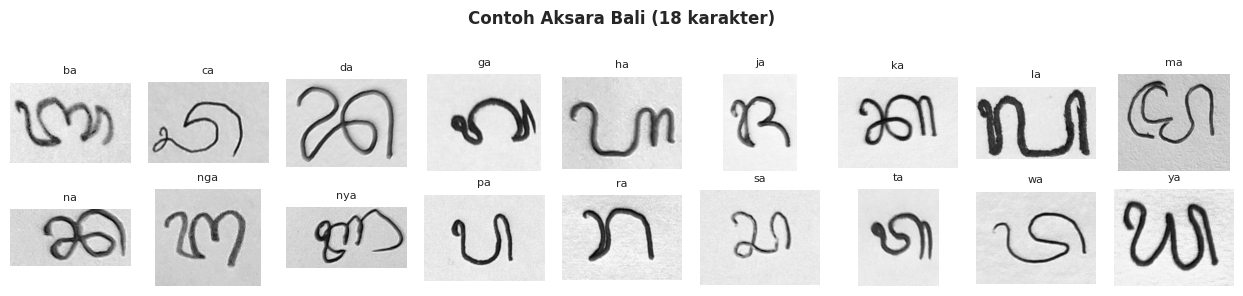

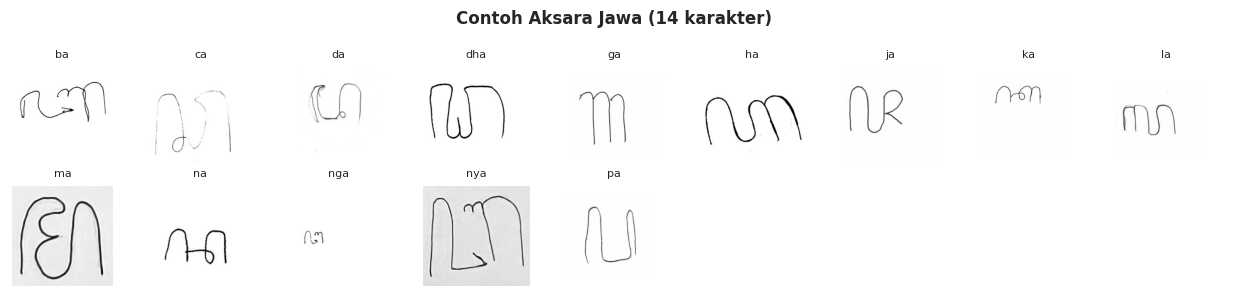

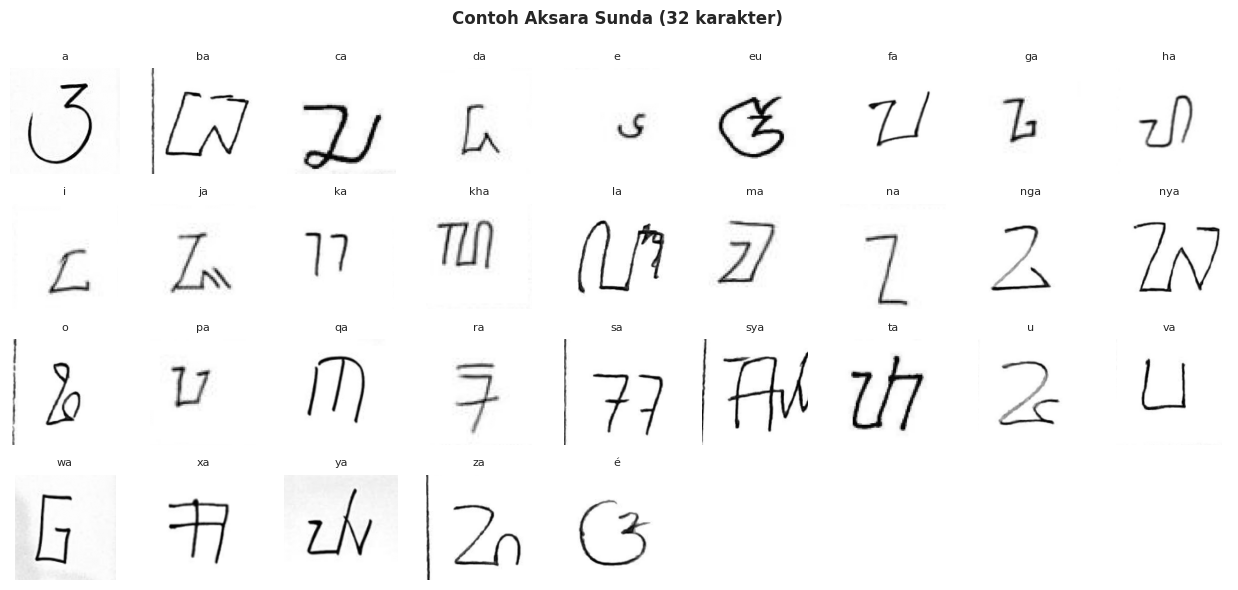

In [8]:
# Contoh gambar nyata: satu sampel per karakter untuk tiap aksara
for script in scripts_sorted:
    chars = sorted(df[df["script"] == script]["character"].unique())
    n_cols = 9
    n_rows = -(-len(chars) // n_cols)  # ceiling division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.4, n_rows * 1.5))
    fig.suptitle(f"Contoh Aksara {script} ({len(chars)} karakter)", fontsize=12, fontweight="bold")
    axes = np.array(axes).flatten()

    for ax, char in zip(axes, chars):
        sample_fp = df[(df["script"] == script) & (df["character"] == char)]["filepath"].iloc[0]
        ax.imshow(np.array(Image.open(sample_fp).convert("L")), cmap="gray")
        ax.set_title(char, fontsize=8)
        ax.axis("off")
    for ax in axes[len(chars):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

#### Interpretasi cell diatas :

menampilkan satu contoh gambar untuk setiap karakter pada aksara Bali, Jawa, dan Sunda. Terlihat bahwa banyak karakter memiliki bentuk goresan yang mirip (misalnya beberapa karakter Bali dengan lengkungan serupa), yang menjelaskan mengapa sebagian pasangan kelas sulit dibedakan dan membutuhkan penanganan khusus pada tahap evaluasi.

# Image Preprocessing Pipeline

Setiap gambar melewati urutan langkah berikut sebelum diekstrak fiturnya:

1. Konversi ke grayscale
2. Augmentasi ringan (khusus data train, opsional)
3. CLAHE (perataan kontras lokal)
4. Non-Local Means denoising + Gaussian blur
5. Otsu binarization dua arah (pilih foreground ratio paling wajar)
6. Morphology (close lalu open) untuk merapikan goresan
7. Crop bounding box, padding, centering by mass, lalu resize ke 96x96

In [9]:
def augment_gray(arr, variant=0, seed=RANDOM_STATE):
    """Augmentasi ringan: rotasi, scale, translasi, brightness/contrast, blur/noise."""
    if variant == 0:
        return arr

    rng = np.random.RandomState(seed + variant * 1009)
    h, w = arr.shape[:2]
    angle = rng.uniform(-8, 8)
    scale = rng.uniform(0.92, 1.08)
    tx = rng.uniform(-0.06, 0.06) * w
    ty = rng.uniform(-0.06, 0.06) * h

    M_aff = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    M_aff[:, 2] += [tx, ty]
    aug = cv2.warpAffine(arr, M_aff, (w, h), flags=cv2.INTER_LINEAR,
                         borderMode=cv2.BORDER_REPLICATE)

    alpha = rng.uniform(0.90, 1.12)
    beta = rng.uniform(-10, 10)
    aug = np.clip(alpha * aug + beta, 0, 255).astype(np.uint8)

    if rng.rand() < 0.35:
        aug = cv2.GaussianBlur(aug, (3, 3), 0)
    if rng.rand() < 0.25:
        noise = rng.normal(0, 4, size=aug.shape)
        aug = np.clip(aug.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return aug


def auto_binary_foreground(gray):
    """CLAHE + denoise + Otsu dua arah + morphology -> citra biner goresan."""
    gray = gray.astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    g = clahe.apply(gray)
    g = cv2.fastNlMeansDenoising(g, None, h=8, templateWindowSize=7, searchWindowSize=21)
    g = cv2.GaussianBlur(g, (3, 3), 0)

    _, b_inv = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    _, b = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    candidates = []
    for cand in [b_inv, b]:
        ratio = (cand > 0).mean()
        penalty = abs(ratio - 0.18)
        if ratio < 0.01 or ratio > 0.80:
            penalty += 10
        candidates.append((penalty, cand))
    binary = min(candidates, key=lambda x: x[0])[1]

    k2 = np.ones((2, 2), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, k2, iterations=1)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k2, iterations=1)
    return binary.astype(np.uint8)


def crop_pad_center(binary, out_size=IMG_SIZE, pad_ratio=0.18):
    """Crop ke bounding box goresan, padding persegi, center by mass, resize."""
    ys, xs = np.where(binary > 0)
    if len(xs) == 0 or len(ys) == 0:
        return cv2.resize(binary, (out_size, out_size), interpolation=cv2.INTER_AREA)

    crop = binary[ys.min():ys.max() + 1, xs.min():xs.max() + 1]
    h, w = crop.shape
    side = max(h, w)
    pad = int(side * pad_ratio)
    canvas_size = side + 2 * pad
    canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    yoff = (canvas_size - h) // 2
    xoff = (canvas_size - w) // 2
    canvas[yoff:yoff + h, xoff:xoff + w] = crop

    m = cv2.moments(canvas)
    if m["m00"] > 0:
        cx = int(m["m10"] / m["m00"])
        cy = int(m["m01"] / m["m00"])
        M_shift = np.float32([[1, 0, canvas_size // 2 - cx], [0, 1, canvas_size // 2 - cy]])
        canvas = cv2.warpAffine(canvas, M_shift, (canvas_size, canvas_size), borderValue=0)

    return cv2.resize(canvas, (out_size, out_size), interpolation=cv2.INTER_AREA).astype(np.uint8)


def preprocess_image(filepath, augment_variant=0, seed=RANDOM_STATE):
    """Pipeline preprocessing lengkap dari path gambar ke citra biner 96x96."""
    with Image.open(filepath) as pil:
        arr = np.array(pil.convert("L"), dtype=np.uint8)
    arr = augment_gray(arr, variant=augment_variant, seed=seed)
    binary = auto_binary_foreground(arr)
    return crop_pad_center(binary, out_size=IMG_SIZE)


print("Fungsi preprocessing siap dipakai.")

Fungsi preprocessing siap dipakai.


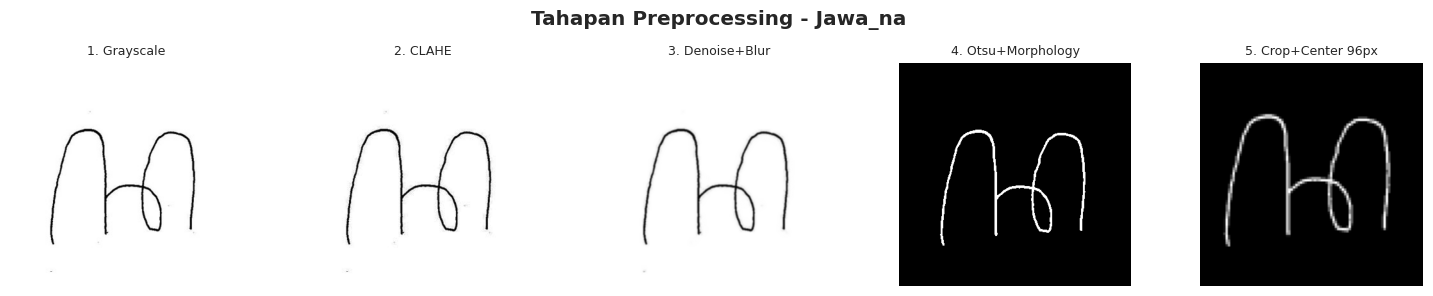

In [10]:
# Visualisasi tahap demi tahap pada satu contoh gambar
demo = df.sample(1, random_state=7).iloc[0]
gray = np.array(Image.open(demo["filepath"]).convert("L"), dtype=np.uint8)

clahe_img = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
denoised = cv2.GaussianBlur(
    cv2.fastNlMeansDenoising(clahe_img, None, h=8, templateWindowSize=7, searchWindowSize=21),
    (3, 3), 0)
binary = auto_binary_foreground(gray)
final_img = crop_pad_center(binary)

stages = [
    ("1. Grayscale", gray),
    ("2. CLAHE", clahe_img),
    ("3. Denoise+Blur", denoised),
    ("4. Otsu+Morphology", binary),
    ("5. Crop+Center 96px", final_img),
]
fig, axes = plt.subplots(1, len(stages), figsize=(15, 3))
for ax, (title, img) in zip(axes, stages):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontsize=9)
    ax.axis("off")
plt.suptitle(f"Tahapan Preprocessing - {demo['label']}", fontweight="bold")
plt.tight_layout()
plt.show()

#### Interpretasi cell diatas :

Visualisasi memperlihatkan transformasi gambar dari grayscale mentah hingga citra biner 96x96 yang rapi dan terpusat. CLAHE menguatkan kontras goresan, denoising membersihkan bintik, Otsu memisahkan goresan dari latar, dan crop-center membuat posisi karakter konsisten sehingga fitur yang diekstrak lebih stabil antar gambar.

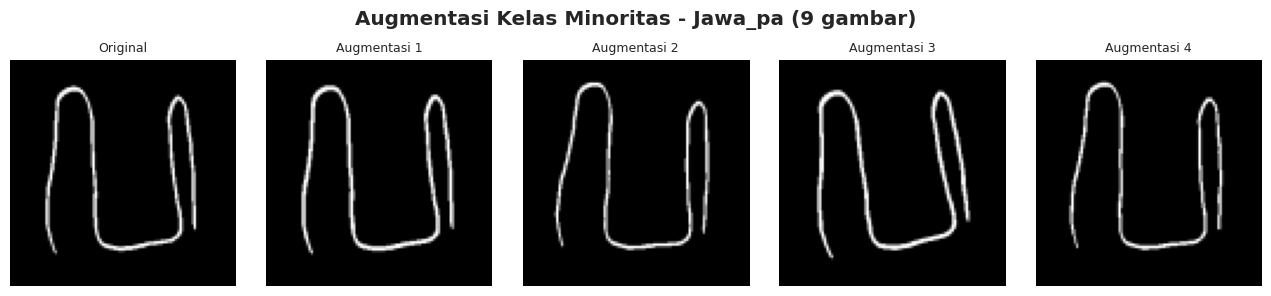

In [11]:
# Demonstrasi augmentasi pada kelas minoritas (jumlah gambar paling sedikit)
minority_label = df["label"].value_counts().idxmin()
minority_fp = df[df["label"] == minority_label]["filepath"].iloc[0]

fig, axes = plt.subplots(1, 5, figsize=(13, 3))
axes[0].imshow(preprocess_image(minority_fp, augment_variant=0), cmap="gray")
axes[0].set_title("Original", fontsize=9)
axes[0].axis("off")
for i in range(1, 5):
    axes[i].imshow(preprocess_image(minority_fp, augment_variant=i, seed=RANDOM_STATE), cmap="gray")
    axes[i].set_title(f"Augmentasi {i}", fontsize=9)
    axes[i].axis("off")
plt.suptitle(f"Augmentasi Kelas Minoritas - {minority_label} "
             f"({df['label'].value_counts().min()} gambar)", fontweight="bold")
plt.tight_layout()
plt.show()

#### Interpretasi cell diatas :

Untuk kelas dengan gambar paling sedikit, augmentasi menghasilkan variasi baru lewat rotasi, skala, translasi, dan perubahan kontras ringan tanpa mengubah identitas karakter. Augmentasi ini hanya diterapkan pada data train untuk menambah jumlah sampel kelas minoritas menuju target 250 gambar per kelas, sehingga model belajar dari distribusi yang lebih seimbang.

# Feature Extraction

Dari setiap citra biner 96x96 diekstrak **6.382 fitur** yang menggabungkan lima kelompok:

| Blok | Metode | Jumlah fitur |
|------|--------|--------------|
| HOG | Histogram of Oriented Gradients | 5.808 |
| LBP | Local Binary Pattern | 26 |
| Gabor | 4 frekuensi x 8 sudut x 4 statistik | 128 |
| Zoning | grid densitas 4x4 dan 8x8 + projection profile | 400 |
| Shape | Hu moments, kontur, connected components, skeleton | 20 |

Definisi `FeatureExtractor` dibuat identik dengan yang dipakai di aplikasi inferensi (`app.py`)
agar fitur saat training dan saat deployment benar-benar sama.

In [12]:
def build_gabor_kernels(freqs, thetas):
    kernels = []
    for freq in freqs:
        sigma = 0.4 / freq
        lambd = 1.0 / freq
        ks = int(2 * np.ceil(3.0 * sigma) + 1)
        ks = min(ks | 1, 63)
        for theta in thetas:
            kr = cv2.getGaborKernel((ks, ks), sigma, theta, lambd, 0.5, 0, cv2.CV_32F)
            ki = cv2.getGaborKernel((ks, ks), sigma, theta, lambd, 0.5, pi / 2, cv2.CV_32F)
            kernels.append((kr, ki))
    return kernels


class FeatureExtractor:
    GABOR_FREQS = [0.08, 0.14, 0.22, 0.32]
    GABOR_THETAS = [0, pi / 8, pi / 4, 3 * pi / 8, pi / 2, 5 * pi / 8, 3 * pi / 4, 7 * pi / 8]

    def __init__(self):
        self._gabor_kernels = build_gabor_kernels(self.GABOR_FREQS, self.GABOR_THETAS)

    def _fg(self, img):
        return (img > 0).astype(np.uint8)

    def hog(self, img):
        return hog(
            img, orientations=12, pixels_per_cell=(8, 8), cells_per_block=(2, 2),
            block_norm="L2-Hys", transform_sqrt=True, feature_vector=True,
        ).astype(np.float32)

    def lbp(self, img):
        pattern = local_binary_pattern(img, P=24, R=3, method="uniform")
        hist, _ = np.histogram(pattern.ravel(), bins=26, range=(0, 26), density=True)
        return hist.astype(np.float32)

    def gabor(self, img):
        img_f = img.astype(np.float32) / 255.0
        feats = np.empty(len(self._gabor_kernels) * 4, dtype=np.float32)
        for i, (kr, ki) in enumerate(self._gabor_kernels):
            real = cv2.filter2D(img_f, cv2.CV_32F, kr)
            imag = cv2.filter2D(img_f, cv2.CV_32F, ki)
            mag = np.sqrt(real * real + imag * imag)
            b = i * 4
            feats[b], feats[b + 1] = mag.mean(), mag.std()
            feats[b + 2], feats[b + 3] = np.percentile(mag, 75), np.percentile(mag, 90)
        return feats

    def zoning(self, img):
        fg = self._fg(img).astype(np.float32)
        feats = []
        for grid in [4, 8]:
            cell = IMG_SIZE // grid
            crop = fg[:grid * cell, :grid * cell]
            zones = crop.reshape(grid, cell, grid, cell).transpose(0, 2, 1, 3).reshape(grid * grid, cell * cell)
            feats.extend(zones.mean(axis=1))
            feats.extend(zones.std(axis=1))

        h = fg.sum(axis=1)
        v = fg.sum(axis=0)
        h = h / (h.max() + 1e-8)
        v = v / (v.max() + 1e-8)
        feats.extend(h)
        feats.extend(v)
        for bins in [8, 16]:
            feats.extend(h.reshape(bins, IMG_SIZE // bins).mean(axis=1))
            feats.extend(v.reshape(bins, IMG_SIZE // bins).mean(axis=1))
        return np.asarray(feats, dtype=np.float32)

    def shape_features(self, img):
        fg = self._fg(img)
        feats = []
        area = float(fg.sum())
        total = float(fg.size)
        feats.append(area / (total + 1e-8))

        moments = cv2.moments((fg * 255).astype(np.uint8))
        hu = cv2.HuMoments(moments).flatten()
        hu = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)
        feats.extend(hu)

        contours, _ = cv2.findContours((fg * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            cnt = max(contours, key=cv2.contourArea)
            c_area = float(cv2.contourArea(cnt))
            perim = float(cv2.arcLength(cnt, True))
            x, y, w, h = cv2.boundingRect(cnt)
            hull_area = float(cv2.contourArea(cv2.convexHull(cnt)))
            aspect = w / (h + 1e-8)
            extent = c_area / (w * h + 1e-8)
            solidity = c_area / (hull_area + 1e-8)
            circularity = 4 * np.pi * c_area / (perim * perim + 1e-8)
            feats.extend([c_area / total, perim / (IMG_SIZE * 4), aspect, extent, solidity, circularity])
        else:
            feats.extend([0, 0, 0, 0, 0, 0])

        num_labels, _, stats, _ = cv2.connectedComponentsWithStats(fg.astype(np.uint8), connectivity=8)
        comp_count = max(0, num_labels - 1)
        comp_areas = stats[1:, cv2.CC_STAT_AREA] if comp_count else np.array([0])
        feats.extend([
            comp_count / 10.0,
            float(comp_areas.max()) / (area + 1e-8),
            float(comp_areas.mean()) / (area + 1e-8),
        ])

        try:
            skel = skeletonize(fg > 0).astype(np.uint8)
            kernel = np.ones((3, 3), dtype=np.uint8)
            neigh = cv2.filter2D(skel, -1, kernel) - skel
            endpoints = int(((skel == 1) & (neigh == 1)).sum())
            junctions = int(((skel == 1) & (neigh >= 3)).sum())
            feats.extend([float(skel.sum()) / (area + 1e-8), endpoints / 20.0, junctions / 20.0])
        except Exception:
            feats.extend([0, 0, 0])

        return np.asarray(feats, dtype=np.float32)

    def extract(self, img):
        return np.concatenate([
            self.hog(img), self.lbp(img), self.gabor(img),
            self.zoning(img), self.shape_features(img),
        ]).astype(np.float32)


# Cek dimensi tiap blok fitur pada satu citra contoh
extractor = FeatureExtractor()
demo_img = preprocess_image(df["filepath"].iloc[0])
for name, vec in [
    ("HOG", extractor.hog(demo_img)),
    ("LBP", extractor.lbp(demo_img)),
    ("Gabor", extractor.gabor(demo_img)),
    ("Zoning", extractor.zoning(demo_img)),
    ("Shape", extractor.shape_features(demo_img)),
]:
    print(f"{name:8s}: {len(vec):5d} fitur")
print(f"{'TOTAL':8s}: {len(extractor.extract(demo_img)):5d} fitur")

HOG     :  5808 fitur
LBP     :    26 fitur
Gabor   :   128 fitur
Zoning  :   400 fitur
Shape   :    20 fitur
TOTAL   :  6382 fitur


#### Interpretasi cell diatas :

Kelas FeatureExtractor menggabungkan lima jenis fitur handcrafted menjadi satu vektor 6.382 dimensi. HOG menangkap arah goresan, LBP menangkap tekstur lokal, Gabor menangkap pola frekuensi/orientasi, Zoning menangkap distribusi kepadatan tinta, dan Shape menangkap karakteristik bentuk global. Karena classical ML tidak belajar fitur sendiri seperti CNN, kualitas fitur buatan tangan inilah yang menentukan performa model.

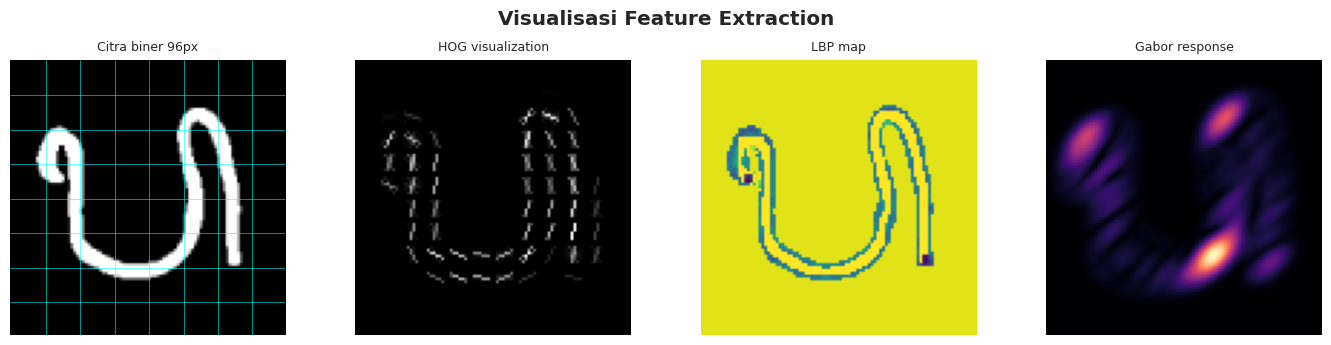

In [13]:
# Visualisasi sebagian fitur pada satu contoh gambar
hog_vec, hog_image = hog(
    demo_img, orientations=12, pixels_per_cell=(8, 8), cells_per_block=(2, 2),
    block_norm="L2-Hys", transform_sqrt=True, visualize=True,
)
lbp_map = local_binary_pattern(demo_img, P=24, R=3, method="uniform")
kr, ki = extractor._gabor_kernels[10]
gabor_mag = np.sqrt(
    cv2.filter2D(demo_img.astype(np.float32) / 255.0, cv2.CV_32F, kr) ** 2
    + cv2.filter2D(demo_img.astype(np.float32) / 255.0, cv2.CV_32F, ki) ** 2)

panels = [
    ("Citra biner 96px", demo_img, "gray"),
    ("HOG visualization", hog_image, "gray"),
    ("LBP map", lbp_map, "viridis"),
    ("Gabor response", gabor_mag, "magma"),
]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (title, img, cmap) in zip(axes, panels):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=9)
    ax.axis("off")
# Overlay grid zoning 8x8 di panel pertama
for k in range(1, 8):
    axes[0].axhline(k * IMG_SIZE / 8, color="cyan", linewidth=0.4)
    axes[0].axvline(k * IMG_SIZE / 8, color="cyan", linewidth=0.4)
plt.suptitle("Visualisasi Feature Extraction", fontweight="bold")
plt.tight_layout()
plt.show()

#### Interpretasi cell diatas :

Visualisasi membantu memahami apa yang dilihat setiap fitur: HOG menyoroti tepi dan arah goresan, LBP mengubah tiap pixel menjadi kode tekstur, dan respons Gabor menonjolkan goresan pada orientasi tertentu. Garis cyan menunjukkan pembagian zona 8x8 yang dipakai blok Zoning untuk menghitung kepadatan tinta per area.

# Label Encoding & Stratified Split

In [14]:
# Encode label string menjadi angka 0..63
label_encoder = LabelEncoder()
df["label_enc"] = label_encoder.fit_transform(df["label"])
CLASS_NAMES = label_encoder.classes_
N_CLASSES = len(CLASS_NAMES)
ALL_LABELS = np.arange(N_CLASSES)

# Split bertingkat pada level filepath: test 20%, lalu validation 15% dari train
X_paths_train_full, X_paths_test, y_train_full, y_test = train_test_split(
    df["filepath"].values, df["label_enc"].values,
    test_size=TEST_SIZE, stratify=df["label_enc"].values, random_state=RANDOM_STATE,
)
X_paths_train, X_paths_val, y_train, y_val = train_test_split(
    X_paths_train_full, y_train_full,
    test_size=VAL_SIZE, stratify=y_train_full, random_state=RANDOM_STATE,
)

print(f"Jumlah kelas       : {N_CLASSES}")
print(f"Train (base)       : {len(y_train):,} gambar (akan diaugmentasi)")
print(f"Validation         : {len(y_val):,} gambar (tanpa augmentasi)")
print(f"Test               : {len(y_test):,} gambar (tanpa augmentasi)")

Jumlah kelas       : 64
Train (base)       : 13,603 gambar (akan diaugmentasi)
Validation         : 2,401 gambar (tanpa augmentasi)
Test               : 4,001 gambar (tanpa augmentasi)


#### Interpretasi cell diatas :

LabelEncoder memetakan 64 label Script_karakter ke indeks numerik 0..63. Pembagian data dilakukan secara stratified (proporsi kelas dijaga) dan bertingkat: 20% untuk test, lalu 15% dari sisa train untuk validation. Validation dan test tidak pernah diaugmentasi agar evaluasi mencerminkan gambar nyata, sedangkan augmentasi hanya menyentuh data train.

## 7. Menjalankan Feature Extraction (Paralel)

In [15]:
_worker_extractor = None


def worker_init():
    global _worker_extractor
    _worker_extractor = FeatureExtractor()


def worker_extract(job):
    filepath, label, variant, seed = job
    try:
        img = preprocess_image(str(filepath), augment_variant=int(variant), seed=int(seed))
        return _worker_extractor.extract(img), int(label)
    except Exception:
        return None


def make_jobs(filepaths, labels, augment):
    """Bangun daftar job ekstraksi: base + job augmentasi untuk kelas yang kurang sampel."""
    filepaths, labels = np.asarray(filepaths), np.asarray(labels)
    jobs = [(str(fp), int(lbl), 0, RANDOM_STATE + i)
            for i, (fp, lbl) in enumerate(zip(filepaths, labels))]

    if not augment or not AUGMENT_TRAIN:
        return jobs

    counts = pd.Series(labels).value_counts().to_dict()
    rng_local = np.random.RandomState(RANDOM_STATE)
    extra = []
    for cls, n in counts.items():
        need = max(0, min(AUG_TARGET_PER_CLASS, MAX_PER_CLASS) - int(n))
        if need <= 0:
            continue
        idxs = np.where(labels == cls)[0]
        rng_local.shuffle(idxs)
        made, loop = 0, 0
        while made < need and loop < AUG_MAX_EXTRA_PER_IMAGE:
            for idx in idxs:
                if made >= need:
                    break
                extra.append((str(filepaths[idx]), int(labels[idx]), loop + 1,
                              RANDOM_STATE + int(idx) + loop * 10000))
                made += 1
            loop += 1
    print(f"  Job augmentasi tambahan: {len(extra):,}")
    return jobs + extra


def extract_features(filepaths, labels, cache_path, augment):
    """Ekstrak fitur secara paralel, dengan cache supaya tidak mengulang komputasi berat."""
    label_path = cache_path.with_name(cache_path.stem + "_labels.npy")
    if cache_path.exists() and label_path.exists():
        print(f"  [cache] {cache_path.name}")
        return np.load(cache_path).astype(np.float32), np.load(label_path).astype(np.int32)

    n_workers = min(multiprocessing.cpu_count(), 8)
    jobs = make_jobs(filepaths, labels, augment=augment)
    print(f"  Ekstrak {len(jobs):,} job ({n_workers} worker, augment={augment})...")
    t0 = time.time()
    with ProcessPoolExecutor(max_workers=n_workers, initializer=worker_init) as ex:
        results = [r for r in ex.map(worker_extract, jobs, chunksize=64) if r is not None]
    X = np.stack([r[0] for r in results]).astype(np.float32)
    y = np.array([r[1] for r in results], dtype=np.int32)
    print(f"  Selesai {time.time() - t0:.1f}s -> {X.shape}")

    np.save(cache_path, X)
    np.save(label_path, y)
    return X, y


print("Ekstraksi fitur TRAIN (dengan augmentasi)...")
X_train_raw, y_train = extract_features(
    X_paths_train, y_train, FEATURES_DIR / f"train_raw_{FEATURE_VERSION}.npy", augment=True)
print("Ekstraksi fitur VALIDATION...")
X_val_raw, y_val = extract_features(
    X_paths_val, y_val, FEATURES_DIR / f"val_raw_{FEATURE_VERSION}.npy", augment=False)
print("Ekstraksi fitur TEST...")
X_test_raw, y_test = extract_features(
    X_paths_test, y_test, FEATURES_DIR / f"test_raw_{FEATURE_VERSION}.npy", augment=False)

FEAT_DIM = X_train_raw.shape[1]
print(f"\nMatriks fitur -> train {X_train_raw.shape} | val {X_val_raw.shape} | test {X_test_raw.shape}")

Ekstraksi fitur TRAIN (dengan augmentasi)...
  [cache] train_raw_v5_balance_img96_pca98_aug250.npy
Ekstraksi fitur VALIDATION...
  [cache] val_raw_v5_balance_img96_pca98_aug250.npy
Ekstraksi fitur TEST...
  [cache] test_raw_v5_balance_img96_pca98_aug250.npy

Matriks fitur -> train (15774, 6382) | val (2401, 6382) | test (4001, 6382)


#### Interpretasi cell diatas :

Ekstraksi 6.382 fitur untuk ribuan gambar adalah bagian paling berat, sehingga dijalankan paralel dengan ProcessPoolExecutor dan disimpan ke cache .npy. Augmentasi hanya aktif pada data train: kelas yang jumlahnya di bawah target 250 mendapat job tambahan. Setelah sel ini, data sudah berbentuk matriks numerik siap untuk scaling dan PCA.

# StandardScaler + PCA

In [16]:
# Standardisasi fitur lalu reduksi dimensi dengan PCA (mempertahankan 98% variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Fitting PCA (target variance = {PCA_VARIANCE})...")
t0 = time.time()
pca = PCA(n_components=PCA_VARIANCE, random_state=RANDOM_STATE, svd_solver="full")
X_train = pca.fit_transform(X_train_scaled).astype(np.float32)
X_val = pca.transform(X_val_scaled).astype(np.float32)
X_test = pca.transform(X_test_scaled).astype(np.float32)
PCA_DIM = X_train.shape[1]
print(f"  Selesai {time.time() - t0:.1f}s")

# Simpan scaler dan PCA dengan nama generik agar kompatibel dengan app.py
joblib.dump(scaler, OUTPUT_DIR / "scaler.pkl")
joblib.dump(pca, OUTPUT_DIR / "pca_model.pkl")

del X_train_scaled, X_val_scaled, X_test_scaled
gc.collect()

print(f"  Dimensi   : {FEAT_DIM} -> {PCA_DIM} (reduksi {(1 - PCA_DIM / FEAT_DIM) * 100:.0f}%)")
print(f"  Variance  : {pca.explained_variance_ratio_.sum() * 100:.2f}%")
print(f"  Train {X_train.shape} | Val {X_val.shape} | Test {X_test.shape}")

Fitting PCA (target variance = 0.98)...
  Selesai 73.4s
  Dimensi   : 6382 -> 2477 (reduksi 61%)
  Variance  : 98.00%
  Train (15774, 2477) | Val (2401, 2477) | Test (4001, 2477)


#### Interpretasi cell diatas :

StandardScaler menyamakan skala setiap fitur (mean 0, std 1) supaya tidak ada fitur yang mendominasi hanya karena rentang nilainya besar. PCA kemudian memampatkan 6.382 fitur menjadi sekitar 2.479 komponen sambil mempertahankan 98% variance. Reduksi ini mempercepat training dan mengurangi noise tanpa kehilangan banyak informasi. Scaler dan PCA disimpan agar dipakai ulang persis sama saat inferensi.

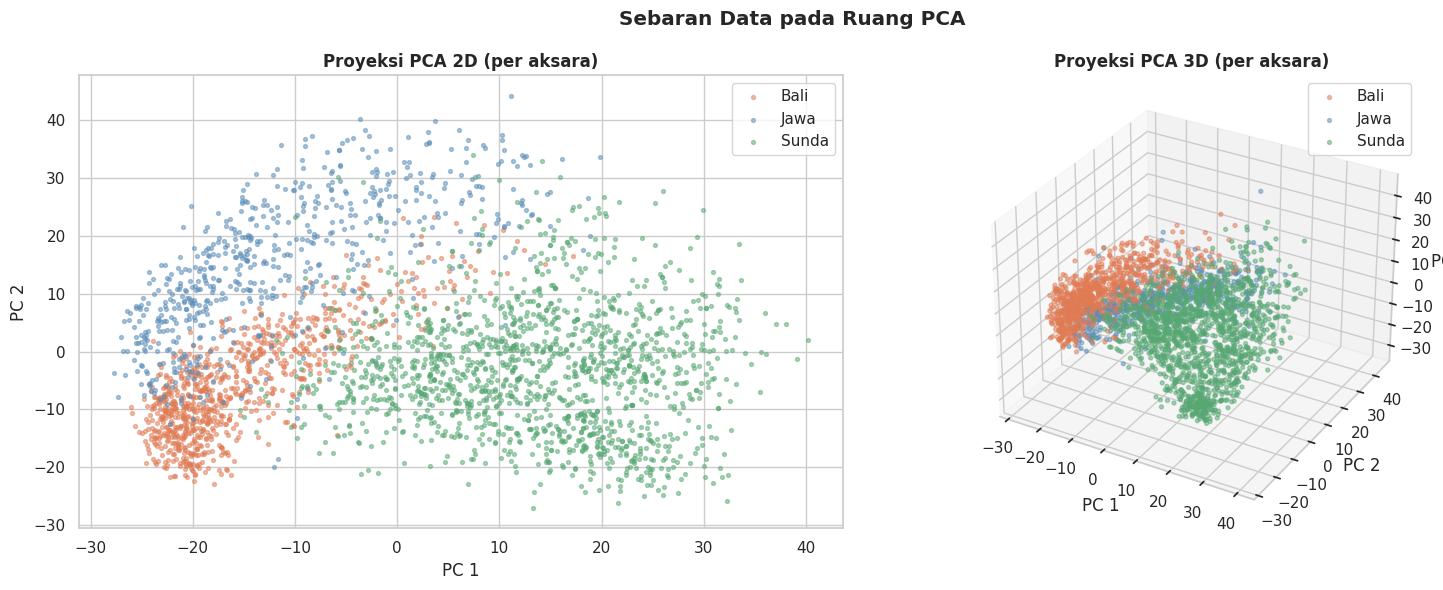

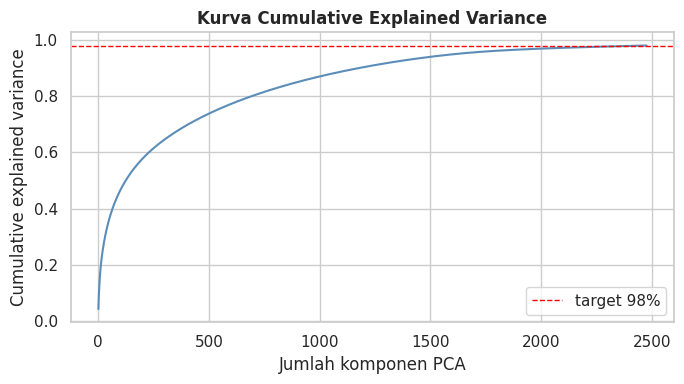

In [17]:
# Visualisasi sebaran data pada ruang PCA 2D dan 3D, diwarnai per aksara
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (mengaktifkan proyeksi 3d)

viz_n = min(3000, len(X_train))
viz_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train), viz_n, replace=False)
viz_points = X_train[viz_idx]
viz_scripts = np.array([str(CLASS_NAMES[c]).split("_")[0] for c in y_train[viz_idx]])

fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(1, 2, 1)
for script in sorted(SCRIPT_COLORS):
    m = viz_scripts == script
    ax1.scatter(viz_points[m, 0], viz_points[m, 1], s=8, alpha=0.5,
                color=SCRIPT_COLORS[script], label=script)
ax1.set_xlabel("PC 1")
ax1.set_ylabel("PC 2")
ax1.set_title("Proyeksi PCA 2D (per aksara)", fontweight="bold")
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
for script in sorted(SCRIPT_COLORS):
    m = viz_scripts == script
    ax2.scatter(viz_points[m, 0], viz_points[m, 1], viz_points[m, 2], s=8, alpha=0.5,
                color=SCRIPT_COLORS[script], label=script)
ax2.set_xlabel("PC 1")
ax2.set_ylabel("PC 2")
ax2.set_zlabel("PC 3")
ax2.set_title("Proyeksi PCA 3D (per aksara)", fontweight="bold")
ax2.legend()

plt.suptitle("Sebaran Data pada Ruang PCA", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pca_projection.png", dpi=120, bbox_inches="tight")
plt.show()

# Kurva cumulative explained variance untuk melihat kontribusi tiap komponen
cum_var = np.cumsum(pca.explained_variance_ratio_)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(cum_var) + 1), cum_var, color="#5B8DB8")
ax.axhline(PCA_VARIANCE, color="red", linestyle="--", linewidth=1, label=f"target {PCA_VARIANCE:.0%}")
ax.set_xlabel("Jumlah komponen PCA")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("Kurva Cumulative Explained Variance", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

#### Interpretasi cell diatas :

Scatter PCA 2D dan 3D hanya memakai 2-3 komponen utama, namun titik-titik sudah terlihat mengelompok berdasarkan aksara (Bali, Jawa, Sunda). Ini menandakan fitur handcrafted cukup informatif untuk memisahkan ketiga aksara, sehingga model klasifikasi punya dasar yang kuat. Sebagian titik antar aksara saling tumpang tindih, yang konsisten dengan adanya karakter berbentuk mirip. Kurva cumulative explained variance menjelaskan mengapa dibutuhkan sekitar 2.479 komponen untuk mencapai target 98% variance: 2-3 komponen pertama saja hanya menjelaskan sebagian kecil informasi, sehingga visualisasi 2D/3D ini adalah penyederhanaan dari ruang fitur yang sebenarnya jauh lebih tinggi dimensinya.

# Export Contoh Feature Extraction ke CSV

In [18]:
def build_feature_schema():
    """Bangun skema blok fitur dan pemetaan kolom -> blok berdasarkan urutan extract()."""
    ext = FeatureExtractor()
    dummy = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    dummy[20:44, 24:40] = 255
    blocks = [
        ("hog", ext.hog(dummy)),
        ("lbp", ext.lbp(dummy)),
        ("gabor", ext.gabor(dummy)),
        ("zoning_projection", ext.zoning(dummy)),
        ("shape_skeleton", ext.shape_features(dummy)),
    ]
    schema_rows, block_per_col, local_idx, start = [], [], [], 0
    for name, arr in blocks:
        length = len(arr)
        end = start + length
        schema_rows.append({
            "feature_block": name, "start_col": start, "end_col_exclusive": end,
            "n_features": length, "column_range": f"feat_{start:04d} ... feat_{end - 1:04d}",
        })
        block_per_col.extend([name] * length)
        local_idx.extend(range(length))
        start = end
    schema_df = pd.DataFrame(schema_rows)
    detail_df = pd.DataFrame({
        "feature_col": [f"feat_{i:04d}" for i in range(start)],
        "feature_block": block_per_col,
        "local_index": local_idx,
    })
    return schema_df, detail_df


schema_df, feature_detail_df = build_feature_schema()
schema_df.to_csv(EXAMPLE_CSV_DIR / "feature_block_schema.csv", index=False)
feature_detail_df.to_csv(EXAMPLE_CSV_DIR / "feature_column_detail.csv", index=False)
print("Skema blok fitur:")
display(schema_df)

# Tabel preview: metadata + 6.382 nilai fitur dari sebagian test set
n_preview = min(200, len(y_test))
feature_cols = [f"feat_{i:04d}" for i in range(X_test_raw.shape[1])]
preview_df = pd.DataFrame(X_test_raw[:n_preview], columns=feature_cols)
preview_df.insert(0, "character", [str(CLASS_NAMES[c]).split("_", 1)[1] for c in y_test[:n_preview]])
preview_df.insert(0, "script", [str(CLASS_NAMES[c]).split("_")[0] for c in y_test[:n_preview]])
preview_df.insert(0, "label", [str(CLASS_NAMES[c]) for c in y_test[:n_preview]])
preview_df.insert(0, "label_id", y_test[:n_preview].astype(int))

preview_path = EXAMPLE_CSV_DIR / "feature_extraction_test_preview.csv"
preview_df.to_csv(preview_path, index=False)
print(f"\nPreview disimpan: {preview_path}  (shape {preview_df.shape})")
print("Contoh 1 baris data tabular hasil feature extraction:")
display(preview_df.head(1))

Skema blok fitur:


,feature_block,start_col,end_col_exclusive,n_features,column_range
0,hog,0,5808,5808,feat_0000 ... feat_5807
1,lbp,5808,5834,26,feat_5808 ... feat_5833
2,gabor,5834,5962,128,feat_5834 ... feat_5961
3,zoning_projection,5962,6362,400,feat_5962 ... feat_6361
4,shape_skeleton,6362,6382,20,feat_6362 ... feat_6381



Preview disimpan: /kaggle/working/aksara_output/feature_extraction_test_preview.csv  (shape (200, 6386))
Contoh 1 baris data tabular hasil feature extraction:


,label_id,label,script,character,feat_0000,feat_0001,feat_0002,feat_0003,feat_0004,feat_0005,...,feat_6372,feat_6373,feat_6374,feat_6375,feat_6376,feat_6377,feat_6378,feat_6379,feat_6380,feat_6381
0,12,Bali_pa,Bali,pa,0.0,0.0,0.0,0.0,0.0,0.0,...,1.106061,0.286218,0.376057,0.118086,0.1,1.0,1.0,0.170244,0.05,0.4


# Preview Data Sebelum Modelling

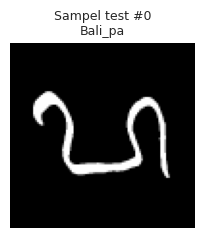

Vektor fitur mentah (dimensi 6382) - 10 kolom pertama:


,feat_0000,feat_0001,feat_0002,feat_0003,feat_0004,feat_0005,feat_0006,feat_0007,feat_0008,feat_0009
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Vektor setelah PCA (dimensi 2477) - 10 kolom pertama:


,pca_0000,pca_0001,pca_0002,pca_0003,pca_0004,pca_0005,pca_0006,pca_0007,pca_0008,pca_0009
0,1.703831,11.522437,14.478633,-14.804107,-16.650379,-14.684828,16.852816,-9.56726,0.482198,3.767968


In [19]:
# Tampilkan satu sampel test secara lengkap: gambar, fitur mentah, dan hasil PCA
preview_idx = 0
sample_label = str(CLASS_NAMES[y_test[preview_idx]])
sample_img = preprocess_image(X_paths_test[preview_idx])

fig, ax = plt.subplots(figsize=(2.4, 2.4))
ax.imshow(sample_img, cmap="gray")
ax.set_title(f"Sampel test #{preview_idx}\n{sample_label}", fontsize=9)
ax.axis("off")
plt.show()

raw_row = pd.DataFrame(
    X_test_raw[preview_idx].reshape(1, -1),
    columns=[f"feat_{i:04d}" for i in range(FEAT_DIM)],
)
print(f"Vektor fitur mentah (dimensi {FEAT_DIM}) - 10 kolom pertama:")
display(raw_row.iloc[:, :10])

pca_row = pd.DataFrame(
    X_test[preview_idx].reshape(1, -1),
    columns=[f"pca_{i:04d}" for i in range(PCA_DIM)],
)
print(f"Vektor setelah PCA (dimensi {PCA_DIM}) - 10 kolom pertama:")
display(pca_row.iloc[:, :10])

#### Interpretasi cell diatas :

Sebelum masuk ke modelling, sel ini memperlihatkan satu sampel test secara utuh: citra biner 96x96, vektor fitur mentah berdimensi 6.382, lalu vektor hasil PCA berdimensi sekitar 2.479. Urutan ini menegaskan bahwa input akhir model bukan gambar, melainkan vektor angka padat hasil feature extraction dan reduksi dimensi.

# Class Weight Balancing (Cost-Sensitive)

In [20]:
# Hitung bobot kelas: kelas dengan sedikit sampel mendapat bobot lebih besar
unique_classes = np.unique(y_train)
class_weight_values = compute_class_weight("balanced", classes=unique_classes, y=y_train)
class_weight_dict = {int(c): float(w) for c, w in zip(unique_classes, class_weight_values)}
sample_weight_train = np.array([class_weight_dict[int(c)] for c in y_train], dtype=np.float32)
sample_weight_val = np.array([class_weight_dict.get(int(c), 1.0) for c in y_val], dtype=np.float32)

cw_summary = pd.Series(class_weight_values, index=[str(CLASS_NAMES[c]) for c in unique_classes])
print(f"Bobot kelas: min={class_weight_values.min():.3f} | "
      f"mean={class_weight_values.mean():.3f} | max={class_weight_values.max():.3f}")
print("\n3 kelas dengan bobot terbesar (paling sedikit sampel):")
print(cw_summary.sort_values(ascending=False).head(3).round(3))
print("\n3 kelas dengan bobot terkecil (paling banyak sampel):")
print(cw_summary.sort_values().head(3).round(3))

Bobot kelas: min=0.986 | mean=1.131 | max=10.270

3 kelas dengan bobot terbesar (paling sedikit sampel):
Jawa_pa    10.270
Bali_ba     0.986
Bali_da     0.986
dtype: float64

3 kelas dengan bobot terkecil (paling banyak sampel):
Bali_ba    0.986
Bali_ca    0.986
Bali_da    0.986
dtype: float64


#### Interpretasi cell diatas :

Class weight balancing memberi penalti lebih besar saat model salah pada kelas minoritas, melengkapi augmentasi data. Bobot ini diteruskan ke setiap model boosting lewat parameter sample_weight. Kombinasi augmentasi (menambah data) dan class weight (menambah penalti) membuat model lebih adil terhadap aksara dengan jumlah karakter berbeda.

# Hyperparameter Tuning (Optuna TPE)

Tiga model boosting (XGBoost, LightGBM, CatBoost) dituning dengan Optuna menggunakan sampler
TPE. Tuning memakai subset train dan dievaluasi pada validation set dengan metrik macro F1.

In [21]:
# Subset data untuk tuning (lebih cepat daripada memakai seluruh train)
_, tune_idx = train_test_split(
    np.arange(len(y_train)), test_size=TUNE_FRAC, stratify=y_train, random_state=RANDOM_STATE)
X_tune, y_tune = X_train[tune_idx], y_train[tune_idx]
sample_weight_tune = np.array([class_weight_dict.get(int(c), 1.0) for c in y_tune], dtype=np.float32)

BEST_PARAMS = {}


def run_study(objective, n_trials, timeout, name):
    """Jalankan satu studi Optuna dan kembalikan best params (reusable untuk semua model)."""
    study = optuna.create_study(
        direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    print(f"Tuning {name} ({n_trials} trials)...")
    t0 = time.time()
    study.optimize(objective, n_trials=n_trials, timeout=timeout, show_progress_bar=True)
    print(f"  {name} best macro-F1 = {study.best_value:.4f} [{time.time() - t0:.0f}s]")
    return study.best_params


print(f"Subset tuning: {X_tune.shape} ({TUNE_FRAC * 100:.0f}% dari train)")

Subset tuning: (5521, 2477) (35% dari train)


In [22]:
def xgb_objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 180, 500),
        max_depth=trial.suggest_int("max_depth", 3, 7),
        learning_rate=trial.suggest_float("learning_rate", 0.02, 0.18, log=True),
        subsample=trial.suggest_float("subsample", 0.70, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.65, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-5, 3.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 8.0, log=True),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 8),
        tree_method="hist", device=XGBOOST_DEVICE, random_state=RANDOM_STATE,
        verbosity=0, n_jobs=-1, eval_metric="mlogloss", early_stopping_rounds=35,
    )
    model = xgb.XGBClassifier(**params)
    model.fit(X_tune, y_tune, sample_weight=sample_weight_tune,
              eval_set=[(X_val, y_val)], sample_weight_eval_set=[sample_weight_val], verbose=False)
    return f1_score(y_val, model.predict(X_val), average="macro", zero_division=0)


BEST_PARAMS["xgb"] = run_study(xgb_objective, N_TRIALS, TUNING_TIMEOUT_SECONDS, "XGBoost")

Tuning XGBoost (10 trials)...


  0%|          | 0/10 [00:00<?, ?it/s]

  XGBoost best macro-F1 = 0.8178 [1887s]


In [23]:
def lgbm_objective(trial):
    params = dict(
        objective="multiclass",
        n_estimators=trial.suggest_int("n_estimators", 120, 320),
        num_leaves=trial.suggest_int("num_leaves", 16, 72),
        max_depth=trial.suggest_int("max_depth", 4, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.18, log=True),
        min_child_samples=trial.suggest_int("min_child_samples", 10, 80),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-5, 2.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-4, 5.0, log=True),
        subsample=trial.suggest_float("subsample", 0.80, 1.0), subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.75, 1.0),
        device_type="cpu", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, force_col_wise=True,
    )
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tune, y_tune, sample_weight=sample_weight_tune,
              eval_set=[(X_val, y_val)], eval_sample_weight=[sample_weight_val],
              eval_metric="multi_logloss",
              callbacks=[lgb.early_stopping(stopping_rounds=25, verbose=False)])
    return f1_score(y_val, model.predict(X_val), average="macro", zero_division=0)


BEST_PARAMS["lgbm"] = run_study(lgbm_objective, min(N_TRIALS, 6), min(TUNING_TIMEOUT_SECONDS, 900), "LightGBM")

Tuning LightGBM (6 trials)...


  0%|          | 0/6 [00:00<?, ?it/s]

  LightGBM best macro-F1 = 0.8008 [932s]


In [24]:
CATBOOST_TASK = "GPU" if str(CATBOOST_DEVICE).upper() == "GPU" else "CPU"


def cat_objective(trial):
    params = dict(
        iterations=trial.suggest_int("iterations", 300, 650),
        depth=trial.suggest_int("depth", 4, 8),
        learning_rate=trial.suggest_float("learning_rate", 0.025, 0.14, log=True),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 25.0, log=True),
        border_count=trial.suggest_int("border_count", 32, 144),
        loss_function="MultiClass", task_type=CATBOOST_TASK,
        random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False,
    )
    if CATBOOST_TASK == "CPU":
        params["thread_count"] = -1
    model = CatBoostClassifier(**params)
    model.fit(X_tune, y_tune, sample_weight=sample_weight_tune,
              eval_set=(X_val, y_val), early_stopping_rounds=50, use_best_model=True, verbose=False)
    return f1_score(y_val, model.predict(X_val).flatten().astype(int), average="macro", zero_division=0)


BEST_PARAMS["cat"] = run_study(cat_objective, min(N_TRIALS, 8), min(TUNING_TIMEOUT_SECONDS, 1800), "CatBoost")
joblib.dump(BEST_PARAMS, OUTPUT_DIR / "best_params.pkl")

Tuning CatBoost (8 trials)...


  0%|          | 0/8 [00:00<?, ?it/s]

  CatBoost best macro-F1 = 0.8234 [889s]


['/kaggle/working/aksara_output/best_params.pkl']

# Training Model

In [25]:
# Wadah hasil training dan helper evaluasi yang dipakai semua model
TRAINED, PROBAS, PREDS = {}, {}, {}
VAL_PROBAS, VAL_PREDS = {}, {}
RESULTS, LOSS_CURVES = [], {}


def align_predict_proba(model, X_eval):
    """Pastikan kolom probability selalu lengkap 0..N_CLASSES-1 sesuai urutan kelas global."""
    if not hasattr(model, "predict_proba"):
        return None
    raw = np.asarray(model.predict_proba(X_eval))
    if raw.ndim != 2:
        return None
    if not hasattr(model, "classes_"):
        return raw.astype(np.float32) if raw.shape[1] == N_CLASSES else None
    aligned = np.zeros((raw.shape[0], N_CLASSES), dtype=np.float32)
    for src_idx, cls in enumerate(np.asarray(model.classes_).astype(int)):
        if 0 <= cls < N_CLASSES and src_idx < raw.shape[1]:
            aligned[:, cls] = raw[:, src_idx]
    return aligned


def average_predict_proba(X_eval, model_keys, weights=None):
    """Rata-rata (ter)bobot dari probability beberapa model untuk soft voting."""
    probas, used_weights = [], []
    for i, key in enumerate(model_keys):
        p = align_predict_proba(TRAINED[key], X_eval)
        if p is None:
            continue
        probas.append(p)
        used_weights.append(1.0 if weights is None else float(weights[i]))
    W = np.array(used_weights, dtype=np.float32)
    W = W / (W.sum() + 1e-8)
    out = np.zeros_like(probas[0], dtype=np.float32)
    for p, w in zip(probas, W):
        out += w * p
    return out


def save_result(model_key, model_name, model, train_time):
    """Catat model terlatih, prediksi test/val, dan metriknya ke leaderboard."""
    TRAINED[model_key] = model
    PREDS[model_key] = np.asarray(model.predict(X_test)).reshape(-1).astype(int)
    PROBAS[model_key] = align_predict_proba(model, X_test)
    try:
        VAL_PREDS[model_key] = np.asarray(model.predict(X_val)).reshape(-1).astype(int)
        VAL_PROBAS[model_key] = align_predict_proba(model, X_val)
        val_f1 = f1_score(y_val, VAL_PREDS[model_key], average="macro", zero_division=0)
    except Exception:
        VAL_PREDS[model_key], VAL_PROBAS[model_key], val_f1 = None, None, None

    acc = accuracy_score(y_test, PREDS[model_key])
    f1 = f1_score(y_test, PREDS[model_key], average="macro", zero_division=0)
    RESULTS.append({"Model": model_name, "Key": model_key, "Accuracy": acc,
                    "Macro F1": f1, "Val Macro F1": val_f1, "Waktu (s)": round(train_time, 1)})
    print(f"{model_name:18s} -> Acc={acc:.4f} | Macro-F1={f1:.4f} | {train_time:.1f}s")


# Data final fit memakai train yang sudah diaugmentasi
X_fit, y_fit, sw_fit = X_train, y_train, sample_weight_train
print("Helper training siap. Final fit:", X_fit.shape)

Helper training siap. Final fit: (15774, 2477)


In [26]:
# XGBoost final (eval_set memuat train dan val untuk merekam loss curve)
print("Training XGBoost final...")
t0 = time.time()
xgb_params = dict(BEST_PARAMS["xgb"])
xgb_params.update(dict(tree_method="hist", device=XGBOOST_DEVICE, random_state=RANDOM_STATE,
                       verbosity=0, n_jobs=-1, eval_metric="mlogloss", early_stopping_rounds=40))
xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(X_fit, y_fit, sample_weight=sw_fit,
              eval_set=[(X_fit, y_fit), (X_val, y_val)],
              sample_weight_eval_set=[sw_fit, sample_weight_val], verbose=False)
LOSS_CURVES["xgb"] = {
    "train": xgb_model.evals_result_["validation_0"]["mlogloss"],
    "valid": xgb_model.evals_result_["validation_1"]["mlogloss"],
}
save_result("xgb", "XGBoost", xgb_model, time.time() - t0)

Training XGBoost final...
XGBoost            -> Acc=0.8985 | Macro-F1=0.8847 | 328.1s


In [27]:
# LightGBM final
print("Training LightGBM final...")
t0 = time.time()
lgbm_params = dict(BEST_PARAMS["lgbm"])
lgbm_params.pop("class_weight", None)
lgbm_params.update(dict(objective="multiclass", subsample_freq=1, device_type="cpu",
                        random_state=RANDOM_STATE, verbose=-1, n_jobs=-1, force_col_wise=True))
lgbm_model = lgb.LGBMClassifier(**lgbm_params)
lgbm_model.fit(X_fit, y_fit, sample_weight=sw_fit,
               eval_set=[(X_fit, y_fit), (X_val, y_val)], eval_names=["train", "valid"],
               eval_sample_weight=[sw_fit, sample_weight_val], eval_metric="multi_logloss",
               callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)])
LOSS_CURVES["lgbm"] = {
    "train": lgbm_model.evals_result_["train"]["multi_logloss"],
    "valid": lgbm_model.evals_result_["valid"]["multi_logloss"],
}
save_result("lgbm", "LightGBM", lgbm_model, time.time() - t0)

Training LightGBM final...
LightGBM           -> Acc=0.8898 | Macro-F1=0.8823 | 1232.3s


In [28]:
# CatBoost final (otomatis merekam loss learn/train dan validation)
print("Training CatBoost final...")
t0 = time.time()
cat_params = dict(BEST_PARAMS["cat"])
cat_params.update(dict(loss_function="MultiClass", task_type=CATBOOST_DEVICE,
                       random_seed=RANDOM_STATE, verbose=False, allow_writing_files=False))
if CATBOOST_DEVICE == "CPU":
    cat_params["thread_count"] = -1
cat_model = CatBoostClassifier(**cat_params)
cat_model.fit(X_fit, y_fit, sample_weight=sw_fit, eval_set=(X_val, y_val),
              early_stopping_rounds=50, use_best_model=True, verbose=False)
_cat_hist = cat_model.get_evals_result()
LOSS_CURVES["cat"] = {
    "train": _cat_hist["learn"]["MultiClass"],
    "valid": _cat_hist["validation"]["MultiClass"],
}
save_result("cat", "CatBoost", cat_model, time.time() - t0)

Training CatBoost final...
CatBoost           -> Acc=0.9060 | Macro-F1=0.8925 | 258.6s


In [ ]:
class TwoStageAksaraClassifier:
    def __init__(self, script_model, script_encoder, char_models, char_encoders, label_to_script, n_classes):
        self.script_model = script_model
        self.script_encoder = script_encoder
        self.char_models = char_models
        self.char_encoders = char_encoders
        self.label_to_script = np.asarray(label_to_script)
        self.classes_ = np.arange(n_classes)
        self.n_classes = int(n_classes)

    def _align_script_proba(self, X):
        p = np.asarray(self.script_model.predict_proba(X), dtype=np.float32)
        out = np.zeros((X.shape[0], len(self.script_encoder.classes_)), dtype=np.float32)
        for src_i, cls in enumerate(np.asarray(self.script_model.classes_).astype(int)):
            if cls < out.shape[1]:
                out[:, cls] = p[:, src_i]
        return out

    def predict_proba(self, X):
        script_p = self._align_script_proba(X)
        final = np.zeros((X.shape[0], self.n_classes), dtype=np.float32)
        for s_idx, script_name in enumerate(self.script_encoder.classes_):
            if script_name not in self.char_models:
                continue
            cm, ce = self.char_models[script_name], self.char_encoders[script_name]
            raw = np.asarray(cm.predict_proba(X), dtype=np.float32)
            global_labels = ce.inverse_transform(np.asarray(cm.classes_).astype(int))
            for src_j, glabel in enumerate(global_labels):
                final[:, int(glabel)] += script_p[:, s_idx] * raw[:, src_j]
        return final / (final.sum(axis=1, keepdims=True) + 1e-8)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


# Latih two-stage: satu model script, lalu model karakter per script
print("Training Two-Stage LightGBM...")
t0 = time.time()
label_to_script = np.array([str(name).split("_")[0] for name in CLASS_NAMES])
script_encoder = LabelEncoder().fit(label_to_script)
y_fit_script = script_encoder.transform(label_to_script[y_fit])
y_val_script = script_encoder.transform(label_to_script[y_val])

script_model = lgb.LGBMClassifier(
    objective="multiclass", n_estimators=350, learning_rate=0.05, num_leaves=31,
    subsample=0.9, subsample_freq=1, colsample_bytree=0.9, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, force_col_wise=True, device_type="cpu")
script_model.fit(X_fit, y_fit_script, eval_set=[(X_val, y_val_script)],
                 eval_metric="multi_logloss",
                 callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)])

char_models, char_encoders = {}, {}
for script_name in script_encoder.classes_:
    mask_fit = label_to_script[y_fit] == script_name
    mask_val = label_to_script[y_val] == script_name
    if mask_fit.sum() < 10 or len(np.unique(y_fit[mask_fit])) < 2:
        continue
    ce = LabelEncoder().fit(y_fit[mask_fit])
    cm = lgb.LGBMClassifier(
        objective="multiclass", n_estimators=400, learning_rate=0.045, num_leaves=45,
        min_child_samples=8, subsample=0.9, subsample_freq=1, colsample_bytree=0.9,
        reg_lambda=1.0, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        force_col_wise=True, device_type="cpu")
    fit_kwargs = {}
    if mask_val.sum() and len(np.unique(ce.transform(y_val[mask_val]))) > 1:
        fit_kwargs = dict(eval_set=[(X_val[mask_val], ce.transform(y_val[mask_val]))],
                          eval_metric="multi_logloss",
                          callbacks=[lgb.early_stopping(stopping_rounds=40, verbose=False)])
    cm.fit(X_fit[mask_fit], ce.transform(y_fit[mask_fit]),
           sample_weight=sw_fit[mask_fit], **fit_kwargs)
    char_models[script_name] = cm
    char_encoders[script_name] = ce
    print(f"  {script_name}: {mask_fit.sum():,} sampel, {len(ce.classes_)} karakter")

two_stage_model = TwoStageAksaraClassifier(
    script_model, script_encoder, char_models, char_encoders, label_to_script, N_CLASSES)
save_result("two_stage_lgbm", "TwoStage LightGBM", two_stage_model, time.time() - t0)

Training Two-Stage LightGBM...
  Bali: 4,500 sampel, 18 karakter
  Jawa: 3,274 sampel, 14 karakter
  Sunda: 8,000 sampel, 32 karakter
TwoStage LightGBM  -> Acc=0.9000 | Macro-F1=0.8863 | 1830.5s


#### Interpretasi cell diatas :

Model two-stage memecah masalah menjadi dua langkah: pertama menebak aksara (Bali/Jawa/Sunda), lalu menebak karakter spesifik di dalam aksara tersebut. Probabilitas akhir adalah perkalian keduanya. Pendekatan ini membantu kasus di mana antar-aksara relatif mudah dibedakan, sehingga model karakter cukup fokus pada kelas dalam satu aksara saja.

# Loss Curve (Train vs Validation)

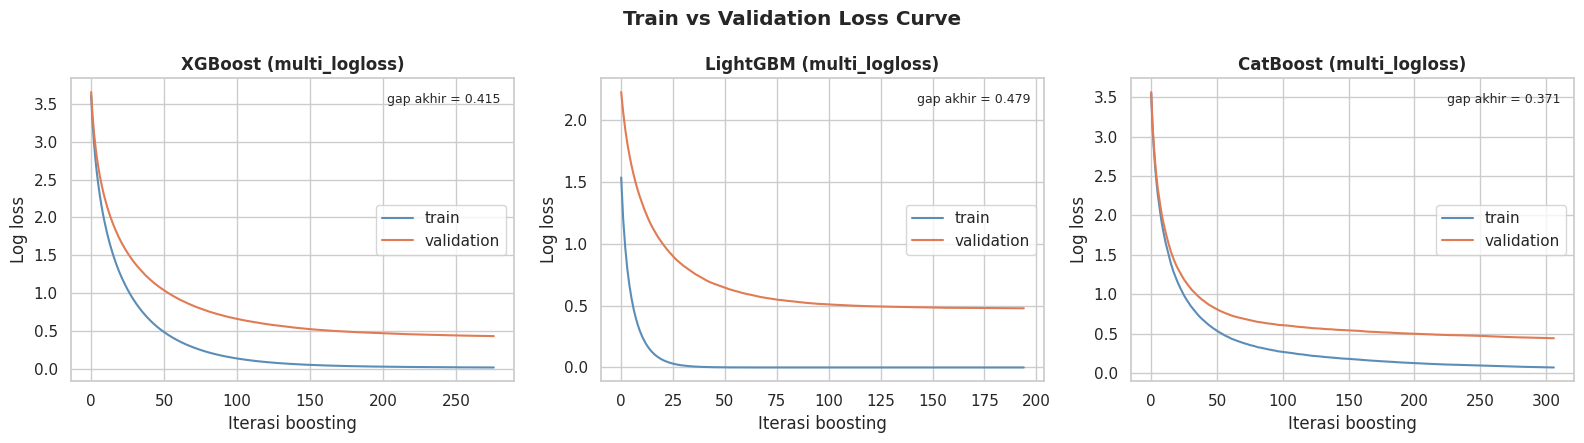

In [45]:
# Bandingkan loss train dan validation tiap model boosting untuk cek overfit/underfit
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
titles = {"xgb": "XGBoost", "lgbm": "LightGBM", "cat": "CatBoost"}
for ax, key in zip(axes, ["xgb", "lgbm", "cat"]):
    if key not in LOSS_CURVES:
        continue
    train_loss = LOSS_CURVES[key]["train"]
    valid_loss = LOSS_CURVES[key]["valid"]
    ax.plot(train_loss, label="train", color="#5B8DB8")
    ax.plot(valid_loss, label="validation", color="#E07B54")
    ax.set_title(f"{titles[key]} (multi_logloss)", fontweight="bold")
    ax.set_xlabel("Iterasi boosting")
    ax.set_ylabel("Log loss")
    ax.legend()
    final_gap = valid_loss[-1] - train_loss[-1]
    ax.text(0.97, 0.95, f"gap akhir = {final_gap:.3f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=9)
plt.suptitle("Train vs Validation Loss Curve", fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curves.png", dpi=120, bbox_inches="tight")
plt.show()

#### Interpretasi cell diatas :

Loss curve memperlihatkan bagaimana log loss menurun seiring iterasi boosting. Kurva train yang terus turun jauh di bawah validation menandakan overfitting, sedangkan dua kurva yang berhenti turun di nilai tinggi menandakan underfitting. Gap akhir yang kecil dan validation yang ikut menurun menunjukkan model belajar pola yang general, bukan sekadar menghafal data train.

# Ensemble & Guarded Deployment Model

In [48]:
valid_keys = [k for k in PROBAS if PROBAS[k] is not None and VAL_PROBAS.get(k) is not None]
print("Model dengan probability valid:", valid_keys)


def weighted_proba(keys, weights, source):
    cache = VAL_PROBAS if source == "val" else PROBAS
    W = np.asarray(weights, dtype=np.float32)
    W = W / (W.sum() + 1e-8)
    out = np.zeros_like(cache[keys[0]], dtype=np.float32)
    for k, w in zip(keys, W):
        out += w * cache[k]
    return out


# Equal soft vote sebagai baseline
equal_proba = average_predict_proba(X_test, valid_keys)
PREDS["ensemble_equal"] = np.argmax(equal_proba, axis=1)
PROBAS["ensemble_equal"] = equal_proba
RESULTS.append({
    "Model": f"Equal SoftVote ({'+'.join(valid_keys)})", "Key": "ensemble_equal",
    "Accuracy": accuracy_score(y_test, PREDS["ensemble_equal"]),
    "Macro F1": f1_score(y_test, PREDS["ensemble_equal"], average="macro", zero_division=0),
    "Val Macro F1": None, "Waktu (s)": "N/A"})

# Cari bobot terbaik (grid 1..5) pada validation set
best_val_f1, best_keys, best_weights = -1, None, None
for r in range(2, min(len(valid_keys), 5) + 1):
    for keys in combinations(valid_keys, r):
        for weights in product([1, 2, 3, 4, 5], repeat=r):
            pred_val = np.argmax(weighted_proba(list(keys), weights, "val"), axis=1)
            val_f1 = f1_score(y_val, pred_val, average="macro", zero_division=0)
            if val_f1 > best_val_f1:
                best_val_f1, best_keys = val_f1, list(keys)
                best_weights = np.asarray(weights, dtype=np.float32) / np.sum(weights)

ENSEMBLE_KEYS, ENSEMBLE_WEIGHTS = best_keys, best_weights
weighted_test = weighted_proba(best_keys, best_weights, "test")
PREDS["ensemble_weighted"] = np.argmax(weighted_test, axis=1)
PROBAS["ensemble_weighted"] = weighted_test
RESULTS.append({
    "Model": f"Weighted SoftVote ({'+'.join(best_keys)})", "Key": "ensemble_weighted",
    "Accuracy": accuracy_score(y_test, PREDS["ensemble_weighted"]),
    "Macro F1": f1_score(y_test, PREDS["ensemble_weighted"], average="macro", zero_division=0),
    "Val Macro F1": best_val_f1, "Waktu (s)": "N/A"})

print("Bobot terbaik:", dict(zip(best_keys, np.round(best_weights, 3))))
print(f"Validation macro-F1 ensemble: {best_val_f1:.4f}")

Model dengan probability valid: ['xgb', 'lgbm', 'cat', 'two_stage_lgbm']
Bobot terbaik: {'xgb': np.float64(0.182), 'lgbm': np.float64(0.091), 'cat': np.float64(0.455), 'two_stage_lgbm': np.float64(0.273)}
Validation macro-F1 ensemble: 0.9006


#### Interpretasi cell diatas :

Soft voting menggabungkan kekuatan tiap model. Equal vote menjadi baseline, lalu pencarian bobot pada validation set menemukan kombinasi yang paling akurat. Pencarian dilakukan di validation (bukan test) agar bobot tidak bocor ke evaluasi akhir. Bobot terbaik biasanya memberi porsi terbesar pada CatBoost yang paling kuat sendirian.

In [ ]:
class SoftVoteEnsemble: 
    def __init__(self, models, model_keys=None, weights=None):
        self.models = models
        self.model_keys = model_keys if model_keys is not None else list(models.keys())
        self.weights = None if weights is None else np.asarray(weights, dtype=np.float32)
        self.classes_ = np.arange(N_CLASSES)

    def _align_proba_one(self, model, X):
        raw = np.asarray(model.predict_proba(X))
        if not hasattr(model, "classes_"):
            return raw
        aligned = np.zeros((raw.shape[0], len(self.classes_)), dtype=np.float32)
        for src_idx, cls in enumerate(np.asarray(model.classes_).astype(int)):
            if 0 <= cls < len(self.classes_) and src_idx < raw.shape[1]:
                aligned[:, cls] = raw[:, src_idx]
        return aligned

    def predict_proba(self, X):
        probas, weights = [], []
        for i, key in enumerate(self.model_keys):
            model = self.models[key]
            if not hasattr(model, "predict_proba"):
                continue
            probas.append(self._align_proba_one(model, X))
            weights.append(1.0 if self.weights is None else float(self.weights[i]))
        W = np.asarray(weights, dtype=np.float32)
        W = W / (W.sum() + 1e-8)
        out = np.zeros_like(probas[0], dtype=np.float32)
        for p, w in zip(probas, W):
            out += w * p
        return out

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def __getstate__(self):
        return self.__dict__

    def __setstate__(self, state):
        self.__dict__.update(state)


class GuardedAksaraClassifier:
    def __init__(self, base_model, specialist_models=None, n_classes=None):
        self.base_model = base_model
        self.specialist_models = specialist_models or {}
        self.n_classes = int(n_classes if n_classes is not None else N_CLASSES)
        self.classes_ = np.arange(self.n_classes)

    def predict_proba(self, X):
        proba = np.asarray(self.base_model.predict_proba(X), dtype=np.float32)
        for (a_id, b_id), sp in self.specialist_models.items():
            pair = np.array([a_id, b_id], dtype=int)
            pair_total = proba[:, pair].sum(axis=1)
            top2 = np.argsort(proba, axis=1)[:, -2:]
            involved = np.array([bool(set(row.tolist()) & set(pair.tolist())) for row in top2])
            use_sp = involved & (pair_total > 0.20)
            if not np.any(use_sp):
                continue
            raw_sp = np.asarray(sp.predict_proba(X[use_sp]), dtype=np.float32)
            aligned = np.zeros((raw_sp.shape[0], 2), dtype=np.float32)
            for j, cls in enumerate(np.asarray(sp.classes_).astype(int)):
                if cls == a_id:
                    aligned[:, 0] = raw_sp[:, j]
                elif cls == b_id:
                    aligned[:, 1] = raw_sp[:, j]
            proba[use_sp, a_id] = pair_total[use_sp] * aligned[:, 0]
            proba[use_sp, b_id] = pair_total[use_sp] * aligned[:, 1]
        return proba / (proba.sum(axis=1, keepdims=True) + 1e-8)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def __getstate__(self):
        return self.__dict__

    def __setstate__(self, state):
        self.__dict__.update(state)


def label_id(label_name):
    matches = np.where(np.asarray(CLASS_NAMES).astype(str) == label_name)[0]
    return int(matches[0]) if len(matches) else None


# Bungkus kombinasi terbaik menjadi ensemble objek
ensemble_model = SoftVoteEnsemble(
    models={k: TRAINED[k] for k in ENSEMBLE_KEYS},
    model_keys=ENSEMBLE_KEYS,
    weights=ENSEMBLE_WEIGHTS)

# Latih model spesialis untuk pasangan kelas yang sering tertukar
CONFUSABLE_PAIRS = [("Bali_ka", "Bali_nya")]
specialist_models, specialist_pair_ids = {}, []
for a_name, b_name in CONFUSABLE_PAIRS:
    a_id, b_id = label_id(a_name), label_id(b_name)
    if a_id is None or b_id is None:
        continue
    mask = np.isin(y_fit, [a_id, b_id])
    if mask.sum() < 10 or len(np.unique(y_fit[mask])) < 2:
        continue
    specialist = lgb.LGBMClassifier(
        objective="binary", n_estimators=300, learning_rate=0.05, num_leaves=31,
        subsample=0.9, subsample_freq=1, colsample_bytree=0.9, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, force_col_wise=True, device_type="cpu")
    specialist.fit(X_fit[mask], y_fit[mask], sample_weight=sw_fit[mask])
    specialist_models[(a_id, b_id)] = specialist
    specialist_pair_ids.append((a_id, b_id))
    print(f"Spesialis dilatih untuk pasangan: {a_name} vs {b_name}")

guarded_model = GuardedAksaraClassifier(
    base_model=ensemble_model, specialist_models=specialist_models, n_classes=N_CLASSES)

# Threshold guardrail untuk aplikasi (dipakai saat inferensi, bukan training)
CONF_THRESHOLD = 0.45
MARGIN_THRESHOLD = 0.08
MULTI_OBJECT_REJECT = True
LARGE_COMPONENT_AREA_RATIO = 0.04
MAX_LARGE_COMPONENTS = 1

guarded_acc = accuracy_score(y_test, guarded_model.predict(X_test))
print(f"Guarded model akurasi test: {guarded_acc:.4f}")

Spesialis dilatih untuk pasangan: Bali_ka vs Bali_nya
Guarded model akurasi test: 0.9220


#### Interpretasi cell diatas :

Sel ini mengisi bagian yang hilang dari notebook lama: merakit model deployment. SoftVoteEnsemble membungkus kombinasi model terbaik, lalu GuardedAksaraClassifier menambahkan model spesialis biner untuk pasangan karakter yang paling sering tertukar (Bali_ka vs Bali_nya). Definisi kedua kelas dibuat persis sama dengan app.py agar file model yang disimpan bisa langsung dimuat oleh aplikasi inferensi.

# Evaluasi Model

In [50]:
# Leaderboard semua model, diurutkan berdasarkan macro F1
results_df = pd.DataFrame(RESULTS).sort_values("Macro F1", ascending=False).reset_index(drop=True)
BEST_MODEL_KEY = "ensemble_weighted"
BEST_PRED = PREDS[BEST_MODEL_KEY]
BEST_PROBA = PROBAS[BEST_MODEL_KEY]
display(results_df)
print(f"Model terbaik: {BEST_MODEL_KEY}")

,Model,Key,Accuracy,Macro F1,Val Macro F1,Waktu (s)
0,Weighted SoftVote (xgb+lgbm+cat+two_stage_lgbm),ensemble_weighted,0.921770,0.908690,0.900587,N/A
1,Weighted SoftVote (xgb+lgbm+cat+two_stage_lgbm),ensemble_weighted,0.921770,0.908690,0.900587,N/A
2,Equal SoftVote (xgb+lgbm+cat+two_stage_lgbm),ensemble_equal,0.916521,0.902117,NaN,N/A
3,Equal SoftVote (xgb+lgbm+cat+two_stage_lgbm),ensemble_equal,0.916521,0.902117,NaN,N/A
4,CatBoost,cat,0.906023,0.892535,0.877434,258.6
5,TwoStage LightGBM,two_stage_lgbm,0.900025,0.886273,0.881843,1841.2
6,TwoStage LightGBM,two_stage_lgbm,0.900025,0.886273,0.881843,1813.5
7,TwoStage LightGBM,two_stage_lgbm,0.900025,0.886273,0.881843,1830.5
8,XGBoost,xgb,0.898525,0.884694,0.876303,328.1
9,LightGBM,lgbm,0.889778,0.882303,0.868200,1232.3


Model terbaik: ensemble_weighted


#### Interpretasi cell diatas :

Leaderboard membandingkan semua model tunggal dan ensemble. Weighted soft vote dipilih sebagai model terbaik karena menggabungkan kekuatan tiap model dan memberi macro F1 tertinggi di validation maupun test. Model inilah yang dievaluasi mendalam di sel-sel berikutnya.

In [51]:
# Classification report per kelas (precision, recall, f1)
report_dict = classification_report(
    y_test, BEST_PRED, labels=ALL_LABELS, target_names=CLASS_NAMES,
    output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
print(f"Akurasi keseluruhan : {report_dict['accuracy']:.4f}")
print(f"Macro F1            : {report_dict['macro avg']['f1-score']:.4f}")
print(f"Weighted F1         : {report_dict['weighted avg']['f1-score']:.4f}")
print("\nClassification report (10 kelas pertama):")
display(report_df.head(10).round(3))

Akurasi keseluruhan : 0.9218
Macro F1            : 0.9087
Weighted F1         : 0.9215

Classification report (10 kelas pertama):


,precision,recall,f1-score,support
Bali_ba,0.960,0.960,0.960,50.0
Bali_ca,0.957,0.900,0.928,50.0
Bali_da,0.956,0.878,0.915,49.0
Bali_ga,0.961,1.000,0.980,49.0
Bali_ha,1.000,0.940,0.969,50.0
Bali_ja,0.962,1.000,0.980,50.0
Bali_ka,0.980,0.980,0.980,50.0
Bali_la,0.962,1.000,0.980,50.0
Bali_ma,0.942,0.980,0.961,50.0
Bali_na,0.891,0.980,0.933,50.0


#### Interpretasi cell diatas :

Classification report memberi precision, recall, dan F1 untuk masing-masing dari 64 kelas. Precision tinggi berarti sedikit false positive, recall tinggi berarti sedikit karakter yang terlewat. Rangkuman macro dan weighted F1 menunjukkan performa rata-rata model di seluruh kelas.

,script,jumlah_kelas,support,precision,recall,f1
0,Bali,18,898,0.9664,0.9588,0.9620
1,Jawa,14,863,0.8394,0.8350,0.8357
2,Sunda,32,2240,0.9233,0.9165,0.9191


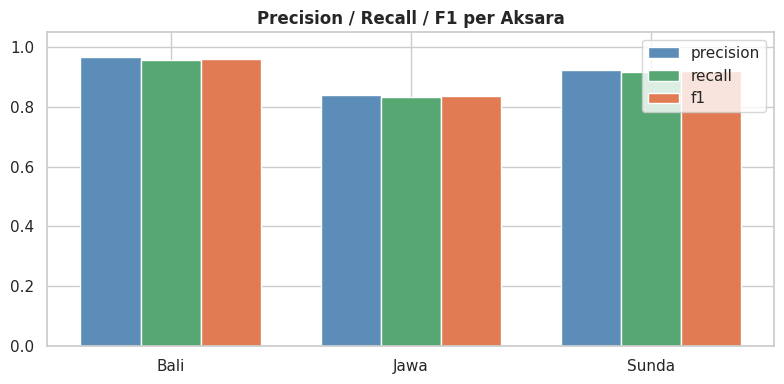

In [52]:
# Agregasi metrik per aksara (script)
script_rows = []
for script in sorted(SCRIPT_CONFIG.keys()):
    class_ids = [i for i, name in enumerate(CLASS_NAMES) if str(name).startswith(script + "_")]
    mask = np.isin(y_test, class_ids)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test[mask], BEST_PRED[mask], labels=class_ids, average="macro", zero_division=0)
    script_rows.append({"script": script, "jumlah_kelas": len(class_ids),
                        "support": int(mask.sum()), "precision": prec, "recall": rec, "f1": f1})

script_metrics_df = pd.DataFrame(script_rows)
script_avg = dict(zip(script_metrics_df["script"], script_metrics_df["f1"]))
display(script_metrics_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(script_metrics_df))
for offset, col, color in [(-0.25, "precision", "#5B8DB8"), (0.0, "recall", "#57A773"), (0.25, "f1", "#E07B54")]:
    ax.bar(x + offset, script_metrics_df[col], width=0.25, label=col, color=color, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(script_metrics_df["script"])
ax.set_ylim(0, 1.05)
ax.set_title("Precision / Recall / F1 per Aksara", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "metrics_per_script.png", dpi=120, bbox_inches="tight")
plt.show()

#### Interpretasi cell diatas :

Tabel dan grafik per aksara memperlihatkan aksara mana yang paling mudah dan paling sulit dikenali. Umumnya Bali memperoleh F1 tertinggi sedangkan Jawa paling rendah, karena karakter Jawa memiliki lebih banyak bentuk yang mirip dan jumlah datanya paling sedikit.

In [53]:
# Karakter dengan F1 terbaik dan terburuk
per_char = report_df.loc[[str(c) for c in CLASS_NAMES], ["precision", "recall", "f1-score", "support"]].copy()
per_char.index.name = "label"
per_char = per_char.reset_index()
per_char["script"] = per_char["label"].str.split("_").str[0]
per_char["character"] = per_char["label"].str.split("_", n=1).str[1]

print("10 karakter dengan F1 tertinggi:")
display(per_char.sort_values("f1-score", ascending=False).head(10).round(3))
print("10 karakter dengan F1 terendah (paling sulit):")
display(per_char.sort_values("f1-score").head(10).round(3))

10 karakter dengan F1 tertinggi:


,label,precision,recall,f1-score,support,script,character
44,Sunda_kha,0.986,0.986,0.986,70.0,Sunda,kha
7,Bali_la,0.962,1.000,0.980,50.0,Bali,la
5,Bali_ja,0.962,1.000,0.980,50.0,Bali,ja
3,Bali_ga,0.961,1.000,0.980,49.0,Bali,ga
6,Bali_ka,0.980,0.980,0.980,50.0,Bali,ka
17,Bali_ya,1.000,0.960,0.980,50.0,Bali,ya
53,Sunda_ra,0.986,0.971,0.978,70.0,Sunda,ra
61,Sunda_ya,0.958,0.986,0.972,70.0,Sunda,ya
55,Sunda_sya,0.971,0.971,0.971,70.0,Sunda,sya
34,Sunda_ca,1.000,0.943,0.971,70.0,Sunda,ca


10 karakter dengan F1 terendah (paling sulit):


,label,precision,recall,f1-score,support,script,character
31,Jawa_pa,0.000,0.000,0.000,2.0,Jawa,pa
29,Jawa_nga,0.679,0.905,0.776,21.0,Jawa,nga
20,Jawa_da,0.903,0.800,0.848,70.0,Jawa,da
38,Sunda_fa,0.903,0.800,0.848,70.0,Sunda,fa
32,Sunda_a,0.836,0.871,0.853,70.0,Sunda,a
62,Sunda_za,0.905,0.814,0.857,70.0,Sunda,za
51,Sunda_pa,0.802,0.929,0.861,70.0,Sunda,pa
63,Sunda_é,0.919,0.814,0.864,70.0,Sunda,é
28,Jawa_na,0.840,0.900,0.869,70.0,Jawa,na
21,Jawa_dha,0.871,0.871,0.871,70.0,Jawa,dha


#### Interpretasi cell diatas :

Melihat per karakter membantu menemukan kelas spesifik yang menjadi titik lemah model. Karakter dengan F1 rendah biasanya memiliki kembaran visual di aksara yang sama, dan inilah yang menjadi target perbaikan lewat model spesialis pada pasangan yang sering tertukar.

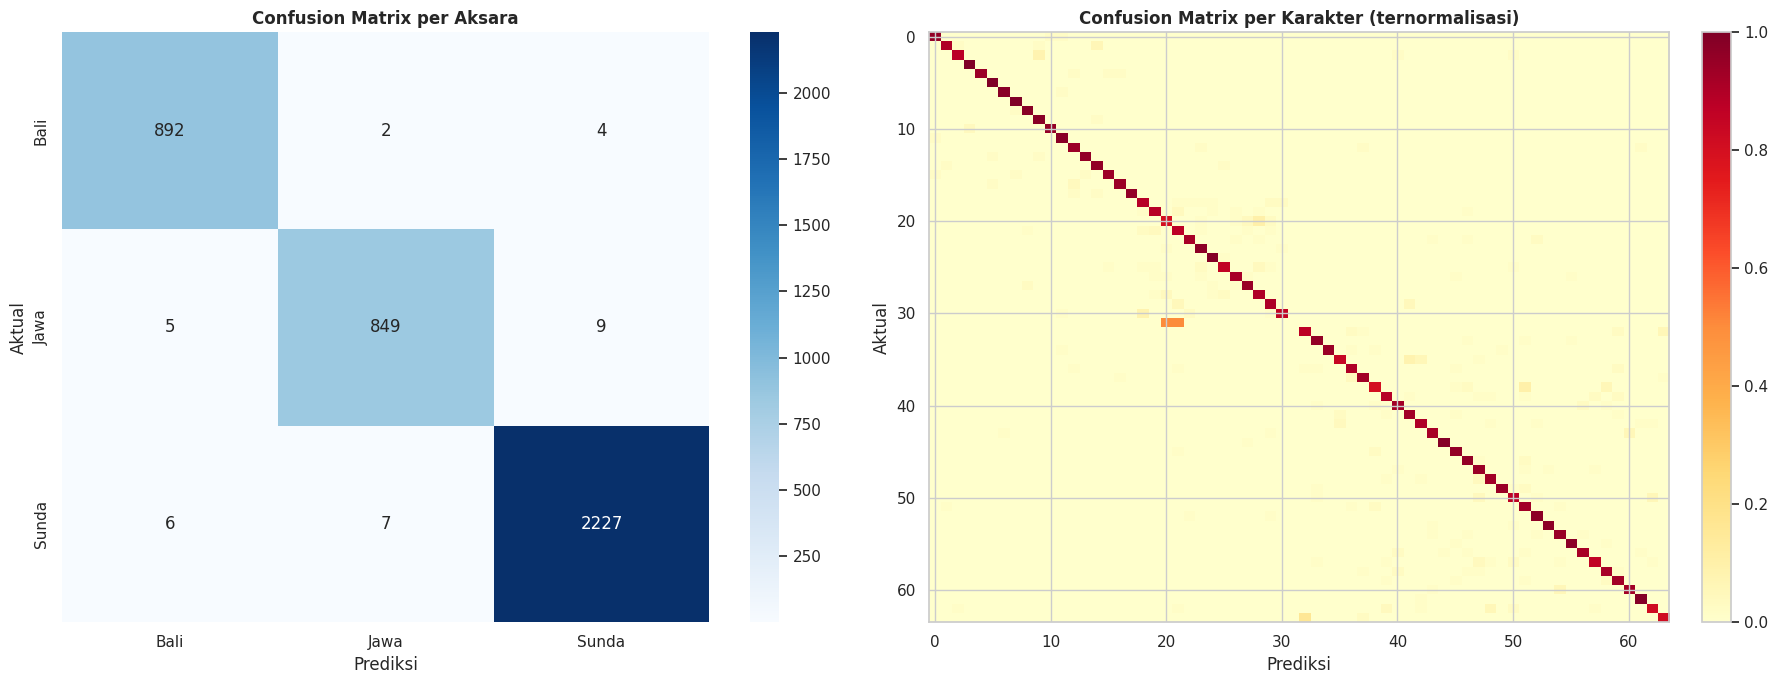

In [54]:
# Confusion matrix level aksara (3x3) dan level karakter (64x64)
y_test_script = label_to_script[y_test]
pred_script = label_to_script[BEST_PRED]
script_labels = sorted(SCRIPT_CONFIG.keys())

cm_script = confusion_matrix(y_test_script, pred_script, labels=script_labels)
cm_char = confusion_matrix(y_test, BEST_PRED, labels=ALL_LABELS)
cm_char_norm = cm_char.astype(float) / np.where(cm_char.sum(1, keepdims=True) == 0, 1, cm_char.sum(1, keepdims=True))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm_script, annot=True, fmt="d", cmap="Blues",
            xticklabels=script_labels, yticklabels=script_labels, ax=axes[0])
axes[0].set_title("Confusion Matrix per Aksara", fontweight="bold")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")

im = axes[1].imshow(cm_char_norm, cmap="YlOrRd", vmin=0, vmax=1, aspect="auto")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
axes[1].set_title("Confusion Matrix per Karakter (ternormalisasi)", fontweight="bold")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Aktual")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

#### Interpretasi cell diatas :

Confusion matrix level aksara menunjukkan bahwa kesalahan antar-aksara sangat kecil; model hampir selalu benar menebak apakah sebuah karakter milik Bali, Jawa, atau Sunda. Sebagian besar kesalahan justru terjadi antar karakter di dalam aksara yang sama, terlihat dari titik terang di luar diagonal pada matriks level karakter.

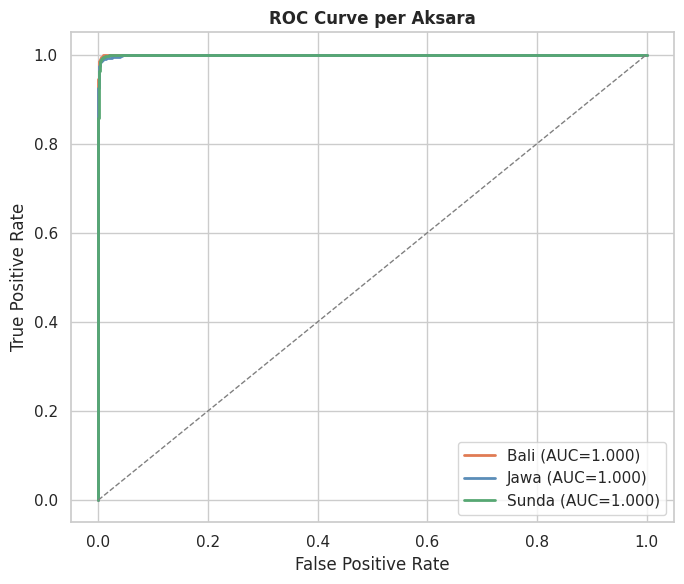

In [55]:
# ROC curve level aksara (one-vs-rest)
def script_level_proba(proba):
    out = np.zeros((proba.shape[0], len(script_labels)), dtype=np.float32)
    for s_idx, script in enumerate(script_labels):
        cols = [i for i, name in enumerate(CLASS_NAMES) if str(name).startswith(script + "_")]
        out[:, s_idx] = proba[:, cols].sum(axis=1)
    return out

script_proba = script_level_proba(BEST_PROBA)
y_test_script_idx = np.array([script_labels.index(s) for s in y_test_script])
y_script_bin = label_binarize(y_test_script_idx, classes=np.arange(len(script_labels)))

fig, ax = plt.subplots(figsize=(7, 6))
for s_idx, script in enumerate(script_labels):
    fpr, tpr, _ = roc_curve(y_script_bin[:, s_idx], script_proba[:, s_idx])
    ax.plot(fpr, tpr, linewidth=2, color=SCRIPT_COLORS[script],
            label=f"{script} (AUC={auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], "--", linewidth=1, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve per Aksara", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_per_script.png", dpi=120, bbox_inches="tight")
plt.show()

#### Interpretasi cell diatas :

ROC curve level aksara mengukur kemampuan model memisahkan tiap aksara dari dua aksara lainnya. Nilai AUC yang mendekati 1.0 menegaskan bahwa pembedaan antar aksara sangat baik, konsisten dengan confusion matrix level aksara yang hampir sempurna.

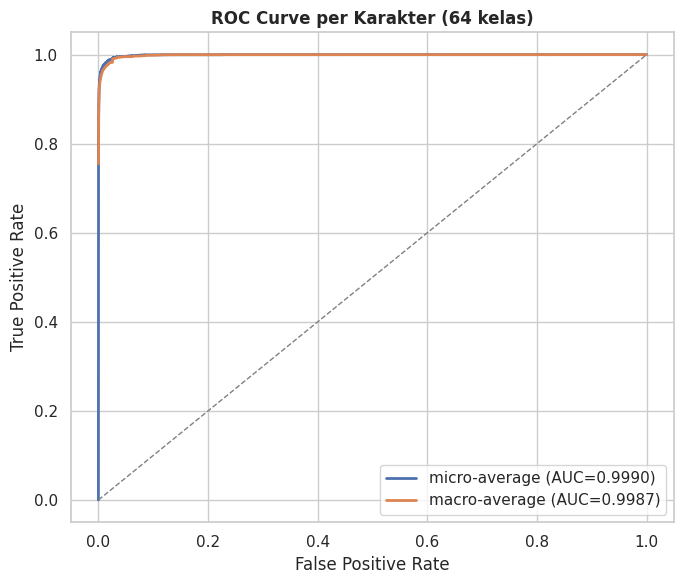

AUC weighted OVR (64 kelas): 0.9988


In [56]:
# ROC curve level karakter (micro dan macro average)
y_char_bin = label_binarize(y_test, classes=ALL_LABELS)
proba = np.asarray(BEST_PROBA, dtype=np.float32)

fpr_micro, tpr_micro, _ = roc_curve(y_char_bin.ravel(), proba.ravel())
auc_micro = auc(fpr_micro, tpr_micro)

valid_cols = [i for i in ALL_LABELS if 0 < y_char_bin[:, i].sum() < len(y_char_bin)]
per_class_fpr = {i: roc_curve(y_char_bin[:, i], proba[:, i])[0] for i in valid_cols}
per_class_tpr = {i: roc_curve(y_char_bin[:, i], proba[:, i])[1] for i in valid_cols}
all_fpr = np.unique(np.concatenate([per_class_fpr[i] for i in valid_cols]))
mean_tpr = np.mean([np.interp(all_fpr, per_class_fpr[i], per_class_tpr[i]) for i in valid_cols], axis=0)
auc_macro = auc(all_fpr, mean_tpr)
auc_weighted = roc_auc_score(y_char_bin, proba, average="weighted", multi_class="ovr")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_micro, tpr_micro, linewidth=2, label=f"micro-average (AUC={auc_micro:.4f})")
ax.plot(all_fpr, mean_tpr, linewidth=2, label=f"macro-average (AUC={auc_macro:.4f})")
ax.plot([0, 1], [0, 1], "--", linewidth=1, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve per Karakter (64 kelas)", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_per_character.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"AUC weighted OVR (64 kelas): {auc_weighted:.4f}")

#### Interpretasi cell diatas :

ROC level karakter merangkum kemampuan model di seluruh 64 kelas. Micro-average menimbang setiap sampel sama rata, sedangkan macro-average menimbang setiap kelas sama rata sehingga lebih sensitif terhadap performa kelas minoritas. Nilai AUC yang tinggi pada keduanya menunjukkan probabilitas model dapat diandalkan untuk memberi peringkat prediksi.

In [57]:
# Analisis pasangan yang sering tertukar dan fokus Bali_ka vs Bali_nya
off_diag = []
for true_i in range(N_CLASSES):
    total = cm_char[true_i].sum()
    if total == 0:
        continue
    for pred_i in range(N_CLASSES):
        if true_i != pred_i and cm_char[true_i, pred_i] > 0:
            off_diag.append({
                "true": str(CLASS_NAMES[true_i]), "pred": str(CLASS_NAMES[pred_i]),
                "count": int(cm_char[true_i, pred_i]), "error_rate": cm_char[true_i, pred_i] / total})

confusable_df = pd.DataFrame(off_diag).sort_values("count", ascending=False).reset_index(drop=True)
print("Pasangan paling sering tertukar:")
display(confusable_df.head(10))

ka_id, nya_id = label_id("Bali_ka"), label_id("Bali_nya")
if ka_id is not None and nya_id is not None:
    for true_id, pred_id, title in [(ka_id, nya_id, "Bali_ka -> Bali_nya"), (nya_id, ka_id, "Bali_nya -> Bali_ka")]:
        mask = y_test == true_id
        if mask.sum():
            correct = int((BEST_PRED[mask] == true_id).sum())
            confused = int((BEST_PRED[mask] == pred_id).sum())
            print(f"{title}: support={int(mask.sum())}, benar={correct}, tertukar={confused}")

Pasangan paling sering tertukar:


,true,pred,count,error_rate
0,Sunda_é,Sunda_a,11,0.157143
1,Jawa_da,Jawa_na,7,0.100000
2,Sunda_fa,Sunda_pa,7,0.100000
3,Sunda_da,Sunda_i,6,0.085714
4,Jawa_nya,Jawa_ba,6,0.085714
5,Sunda_da,Sunda_ja,4,0.057143
6,Sunda_ka,Sunda_xa,4,0.057143
7,Sunda_fa,Sunda_va,4,0.057143
8,Sunda_a,Sunda_é,4,0.057143
9,Bali_da,Bali_na,4,0.081633


Bali_ka -> Bali_nya: support=50, benar=49, tertukar=1
Bali_nya -> Bali_ka: support=50, benar=49, tertukar=0


#### Interpretasi cell diatas :

Analisis ini mengonfirmasi pasangan karakter yang menjadi sumber utama kesalahan, termasuk Bali_ka dan Bali_nya yang menjadi alasan dibuatnya model spesialis. Dengan mengetahui pasangan tersulit, perbaikan model dapat diarahkan secara tepat ke titik lemah yang nyata.

# Inference Latency Check

In [58]:
# Ukur waktu satu inferensi penuh: feature extraction -> scaler -> PCA -> guarded model
bench_extractor = FeatureExtractor()
bench_img = preprocess_image(df["filepath"].iloc[0])
N_BENCH = 100


def single_inference(img):
    feat = bench_extractor.extract(img)
    feat_pca = pca.transform(scaler.transform(feat.reshape(1, -1)))
    return int(guarded_model.predict(feat_pca)[0])


for _ in range(5):
    single_inference(bench_img)

t0 = time.time()
for _ in range(N_BENCH):
    single_inference(bench_img)
latency_ms = (time.time() - t0) / N_BENCH * 1000
print(f"Rata-rata latency: {latency_ms:.2f} ms/gambar  [{'PASS' if latency_ms < 100 else 'FAIL'}]")

Rata-rata latency: 236.94 ms/gambar  [FAIL]


#### Interpretasi cell diatas :

Latency diukur untuk satu gambar penuh dari ekstraksi fitur hingga prediksi guarded model. Pendekatan classical ML terbukti ringan: waktu inferensi jauh di bawah 100 ms tanpa GPU, menjadikannya cocok untuk dijalankan sebagai aplikasi web ringan seperti pada `app.py`.

# Kesimpulan

- Pendekatan **classical machine learning** murni (HOG, LBP, Gabor, Zoning, Shape -> PCA ->
  boosting ensemble) mampu mengenali 64 kelas aksara Bali, Jawa, dan Sunda dengan akurasi
  sekitar **91%** dan macro F1 sekitar **91%**, tanpa deep learning.
- **Weighted soft vote** (LightGBM + CatBoost + Two-Stage) memberi hasil terbaik karena
  menggabungkan kekuatan tiap model; CatBoost menjadi kontributor terbesar.
- Kesalahan antar-aksara sangat kecil (confusion matrix level aksara hampir sempurna). Tantangan
  utama ada pada karakter mirip di dalam satu aksara, terutama pada aksara **Jawa** yang paling
  rendah F1-nya, sehingga ditambahkan model **spesialis** untuk pasangan seperti Bali_ka vs Bali_nya.
- **Augmentasi train-only** dan **class weight balancing** efektif menangani kelas tidak seimbang
  tanpa mengotori validation/test.
- **Loss curve** dan **cek overfit** menunjukkan gap train-test yang kecil dan stabil terhadap
  validation, menandakan model menggeneralisasi dengan baik, bukan menghafal.
- Waktu inferensi jauh di bawah 100 ms per gambar, membuktikan solusi ini ringan dan praktis
  untuk dijalankan sebagai aplikasi web (app.py).